In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from tensorflow.keras.layers import Dense, Flatten, Input, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from keras.models import Sequential
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [3]:
import splitfolders # or import splitfolders
input_folder = "archive/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset"
output = "output" #where you want the split datasets saved. one will be created if it does not exist or none is set

splitfolders.ratio(input_folder, output=output, seed=42, ratio=(.7, .3,)) # ratio of split are in order of train/val/test. You can change to whatever you want. For train/val sets only, you could do .75, .25 for example.

Copying files: 1097 files [00:01, 811.09 files/s]


In [4]:
train_path = "output/train"
test_path = "output/val"

In [5]:
IMAGE_SIZE = [128,128]

In [6]:
# Scaling all the images between 0 to 1

train_datagen = ImageDataGenerator(rescale = 1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=False)

# Performing only scaling on the test dataset

test_datagen = ImageDataGenerator(rescale=1./255)

In [36]:
train_set = train_datagen.flow_from_directory(train_path,
                                              target_size=(128,128),
                                              batch_size=2,
                                              class_mode = 'categorical')

test_set = test_datagen.flow_from_directory(test_path,
                                            target_size=(128,128),
                                            batch_size=2,
                                            class_mode='categorical')

Found 767 images belonging to 3 classes.
Found 330 images belonging to 3 classes.


In [37]:
from keras import backend as K

def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [38]:
from keras.metrics import Precision, Recall
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential, Model

learning_rate_reduction = ReduceLROnPlateau(
    monitor="val_accuracy", patience=3, verbose=1, factor=0.3, min_lr=0.0000001
)
early_stop = EarlyStopping(
    patience=10,
    verbose=1,
    monitor="val_accuracy",
    mode="max",
    min_delta=0.001,
    restore_best_weights=True,
)

In [39]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

# VGG16

In [40]:
vgg16=VGG16(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [41]:
x1= Flatten()(vgg16.output)
prediction1 = Dense(3, activation='softmax')(x1)
model1 = Model(inputs = vgg16.inputs, outputs = prediction1)
model1.summary()
model1.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_6 (InputLayer)         [(None, 128, 128, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 128, 128, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 128, 128, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 64, 64, 64)        0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 64, 64, 128)       73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 64, 64, 128)       147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 32, 32, 128)       0   

In [42]:
hist1 = model1.fit(train_set, validation_data=test_set, epochs=20, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/20


 82/384 [=====>........................] - ETA: 8:49 - loss: 1.0951 - accuracy: 0.0000e+00 - f1_m: 0.0000e+00 - precision_m: 0.0000e+00 - recall_m: 0.0000e+ - ETA: 2:22 - loss: 4.3672 - accuracy: 0.2500 - f1_m: 0.2500 - precision_m: 0.2500 - recall_m: 0.2500               - ETA: 2:22 - loss: 3.4150 - accuracy: 0.1667 - f1_m: 0.1667 - precision_m: 0.1667 - recall_m: 0.16 - ETA: 2:22 - loss: 2.9894 - accuracy: 0.1250 - f1_m: 0.1250 - precision_m: 0.1250 - recall_m: 0.12 - ETA: 2:20 - loss: 3.1345 - accuracy: 0.1000 - f1_m: 0.1000 - precision_m: 0.1000 - recall_m: 0.10 - ETA: 2:20 - loss: 2.7844 - accuracy: 0.1667 - f1_m: 0.1667 - precision_m: 0.1667 - recall_m: 0.16 - ETA: 2:20 - loss: 2.4962 - accuracy: 0.2143 - f1_m: 0.2143 - precision_m: 0.2143 - recall_m: 0.21 - ETA: 2:20 - loss: 2.6225 - accuracy: 0.1875 - f1_m: 0.1875 - precision_m: 0.1875 - recall_m: 0.18 - ETA: 2:19 - loss: 2.4538 - accuracy: 0.2222 - f1_m: 0.2222 - precision_m: 0.2222 - recall_m: 0.22 - ETA: 2:19 - loss: 2.3203 

246/384 [==================>...........] - ETA: 1:38 - loss: 1.2155 - accuracy: 0.4468 - f1_m: 0.2707 - precision_m: 0.2727 - recall_m: 0.26 - ETA: 1:38 - loss: 1.2159 - accuracy: 0.4441 - f1_m: 0.2691 - precision_m: 0.2711 - recall_m: 0.26 - ETA: 1:38 - loss: 1.2169 - accuracy: 0.4444 - f1_m: 0.2705 - precision_m: 0.2725 - recall_m: 0.26 - ETA: 1:38 - loss: 1.2147 - accuracy: 0.4448 - f1_m: 0.2688 - precision_m: 0.2708 - recall_m: 0.26 - ETA: 1:38 - loss: 1.2125 - accuracy: 0.4451 - f1_m: 0.2673 - precision_m: 0.2692 - recall_m: 0.26 - ETA: 1:38 - loss: 1.2135 - accuracy: 0.4454 - f1_m: 0.2657 - precision_m: 0.2676 - recall_m: 0.26 - ETA: 1:38 - loss: 1.2136 - accuracy: 0.4457 - f1_m: 0.2641 - precision_m: 0.2661 - recall_m: 0.26 - ETA: 1:38 - loss: 1.2130 - accuracy: 0.4431 - f1_m: 0.2626 - precision_m: 0.2645 - recall_m: 0.26 - ETA: 1:37 - loss: 1.2132 - accuracy: 0.4406 - f1_m: 0.2611 - precision_m: 0.2630 - recall_m: 0.26 - ETA: 1:37 - loss: 1.2115 - accuracy: 0.4438 - f1_m: 0.259

328/384 [========================>.....] - ETA: 1:18 - loss: 1.1476 - accuracy: 0.4523 - f1_m: 0.2429 - precision_m: 0.2470 - recall_m: 0.24 - ETA: 1:17 - loss: 1.1497 - accuracy: 0.4505 - f1_m: 0.2419 - precision_m: 0.2460 - recall_m: 0.23 - ETA: 1:17 - loss: 1.1490 - accuracy: 0.4487 - f1_m: 0.2410 - precision_m: 0.2450 - recall_m: 0.23 - ETA: 1:16 - loss: 1.1477 - accuracy: 0.4489 - f1_m: 0.2420 - precision_m: 0.2460 - recall_m: 0.24 - ETA: 1:16 - loss: 1.1464 - accuracy: 0.4491 - f1_m: 0.2430 - precision_m: 0.2470 - recall_m: 0.24 - ETA: 1:15 - loss: 1.1451 - accuracy: 0.4493 - f1_m: 0.2421 - precision_m: 0.2460 - recall_m: 0.24 - ETA: 1:15 - loss: 1.1443 - accuracy: 0.4475 - f1_m: 0.2411 - precision_m: 0.2451 - recall_m: 0.23 - ETA: 1:14 - loss: 1.1457 - accuracy: 0.4458 - f1_m: 0.2402 - precision_m: 0.2441 - recall_m: 0.23 - ETA: 1:14 - loss: 1.1445 - accuracy: 0.4460 - f1_m: 0.2392 - precision_m: 0.2431 - recall_m: 0.23 - ETA: 1:13 - loss: 1.1456 - accuracy: 0.4442 - f1_m: 0.238

384/384 [==============================] - ETA: 35s - loss: 1.1179 - accuracy: 0.4490 - f1_m: 0.2295 - precision_m: 0.2325 - recall_m: 0.228 - ETA: 34s - loss: 1.1175 - accuracy: 0.4476 - f1_m: 0.2288 - precision_m: 0.2318 - recall_m: 0.227 - ETA: 33s - loss: 1.1166 - accuracy: 0.4478 - f1_m: 0.2281 - precision_m: 0.2311 - recall_m: 0.226 - ETA: 33s - loss: 1.1157 - accuracy: 0.4480 - f1_m: 0.2274 - precision_m: 0.2304 - recall_m: 0.225 - ETA: 32s - loss: 1.1145 - accuracy: 0.4496 - f1_m: 0.2267 - precision_m: 0.2297 - recall_m: 0.225 - ETA: 31s - loss: 1.1136 - accuracy: 0.4498 - f1_m: 0.2260 - precision_m: 0.2290 - recall_m: 0.224 - ETA: 31s - loss: 1.1123 - accuracy: 0.4514 - f1_m: 0.2284 - precision_m: 0.2313 - recall_m: 0.226 - ETA: 30s - loss: 1.1137 - accuracy: 0.4516 - f1_m: 0.2292 - precision_m: 0.2321 - recall_m: 0.227 - ETA: 30s - loss: 1.1122 - accuracy: 0.4532 - f1_m: 0.2315 - precision_m: 0.2344 - recall_m: 0.230 - ETA: 29s - loss: 1.1113 - accuracy: 0.4533 - f1_m: 0.2322

...

384/384 [==============================] - ETA: 39s - loss: 0.9612 - accuracy: 0.4992 - f1_m: 0.2979 - precision_m: 0.2979 - recall_m: 0.297 - ETA: 38s - loss: 0.9604 - accuracy: 0.5008 - f1_m: 0.2970 - precision_m: 0.2970 - recall_m: 0.297 - ETA: 37s - loss: 0.9600 - accuracy: 0.5008 - f1_m: 0.2961 - precision_m: 0.2961 - recall_m: 0.296 - ETA: 37s - loss: 0.9596 - accuracy: 0.5008 - f1_m: 0.2952 - precision_m: 0.2952 - recall_m: 0.295 - ETA: 36s - loss: 0.9588 - accuracy: 0.5023 - f1_m: 0.2943 - precision_m: 0.2943 - recall_m: 0.294 - ETA: 35s - loss: 0.9584 - accuracy: 0.5022 - f1_m: 0.2934 - precision_m: 0.2934 - recall_m: 0.293 - ETA: 34s - loss: 0.9598 - accuracy: 0.5022 - f1_m: 0.2925 - precision_m: 0.2925 - recall_m: 0.292 - ETA: 34s - loss: 0.9591 - accuracy: 0.5037 - f1_m: 0.2917 - precision_m: 0.2917 - recall_m: 0.291 - ETA: 33s - loss: 0.9605 - accuracy: 0.5037 - f1_m: 0.2908 - precision_m: 0.2908 - recall_m: 0.290 - ETA: 32s - loss: 0.9601 - accuracy: 0.5037 - f1_m: 0.2899

 82/384 [=====>........................] - ETA: 4:35 - loss: 0.8162 - accuracy: 0.5000 - f1_m: 0.5000 - precision_m: 0.5000 - recall_m: 0.50 - ETA: 4:24 - loss: 0.7454 - accuracy: 0.7500 - f1_m: 0.7500 - precision_m: 0.7500 - recall_m: 0.75 - ETA: 4:29 - loss: 0.7690 - accuracy: 0.6667 - f1_m: 0.6667 - precision_m: 0.6667 - recall_m: 0.66 - ETA: 4:28 - loss: 0.7807 - accuracy: 0.6250 - f1_m: 0.6250 - precision_m: 0.6250 - recall_m: 0.62 - ETA: 4:29 - loss: 0.7877 - accuracy: 0.6000 - f1_m: 0.6000 - precision_m: 0.6000 - recall_m: 0.60 - ETA: 4:29 - loss: 0.9230 - accuracy: 0.5000 - f1_m: 0.5000 - precision_m: 0.5000 - recall_m: 0.50 - ETA: 4:28 - loss: 0.9077 - accuracy: 0.5000 - f1_m: 0.5000 - precision_m: 0.5000 - recall_m: 0.50 - ETA: 4:27 - loss: 0.9140 - accuracy: 0.4375 - f1_m: 0.4375 - precision_m: 0.4375 - recall_m: 0.43 - ETA: 4:25 - loss: 0.9031 - accuracy: 0.4444 - f1_m: 0.4444 - precision_m: 0.4444 - recall_m: 0.44 - ETA: 4:25 - loss: 0.9086 - accuracy: 0.4000 - f1_m: 0.400

246/384 [==================>...........] - ETA: 2:35 - loss: 0.9582 - accuracy: 0.5076 - f1_m: 0.5061 - precision_m: 0.5061 - recall_m: 0.50 - ETA: 2:34 - loss: 0.9573 - accuracy: 0.5076 - f1_m: 0.5060 - precision_m: 0.5060 - recall_m: 0.50 - ETA: 2:33 - loss: 0.9612 - accuracy: 0.5045 - f1_m: 0.5030 - precision_m: 0.5030 - recall_m: 0.50 - ETA: 2:33 - loss: 0.9594 - accuracy: 0.5075 - f1_m: 0.5060 - precision_m: 0.5060 - recall_m: 0.50 - ETA: 2:32 - loss: 0.9577 - accuracy: 0.5104 - f1_m: 0.5089 - precision_m: 0.5089 - recall_m: 0.50 - ETA: 2:31 - loss: 0.9653 - accuracy: 0.5074 - f1_m: 0.5059 - precision_m: 0.5059 - recall_m: 0.50 - ETA: 2:31 - loss: 0.9690 - accuracy: 0.5044 - f1_m: 0.5029 - precision_m: 0.5029 - recall_m: 0.50 - ETA: 2:30 - loss: 0.9763 - accuracy: 0.5015 - f1_m: 0.5000 - precision_m: 0.5000 - recall_m: 0.50 - ETA: 2:29 - loss: 0.9754 - accuracy: 0.5014 - f1_m: 0.5000 - precision_m: 0.5000 - recall_m: 0.50 - ETA: 2:28 - loss: 0.9781 - accuracy: 0.5014 - f1_m: 0.500

328/384 [========================>.....] - ETA: 1:37 - loss: 0.9477 - accuracy: 0.5132 - f1_m: 0.5121 - precision_m: 0.5121 - recall_m: 0.51 - ETA: 1:36 - loss: 0.9472 - accuracy: 0.5131 - f1_m: 0.5121 - precision_m: 0.5121 - recall_m: 0.51 - ETA: 1:35 - loss: 0.9472 - accuracy: 0.5111 - f1_m: 0.5100 - precision_m: 0.5100 - recall_m: 0.51 - ETA: 1:35 - loss: 0.9461 - accuracy: 0.5130 - f1_m: 0.5120 - precision_m: 0.5120 - recall_m: 0.51 - ETA: 1:34 - loss: 0.9462 - accuracy: 0.5110 - f1_m: 0.5100 - precision_m: 0.5100 - recall_m: 0.51 - ETA: 1:33 - loss: 0.9456 - accuracy: 0.5109 - f1_m: 0.5099 - precision_m: 0.5099 - recall_m: 0.50 - ETA: 1:32 - loss: 0.9457 - accuracy: 0.5089 - f1_m: 0.5079 - precision_m: 0.5079 - recall_m: 0.50 - ETA: 1:32 - loss: 0.9458 - accuracy: 0.5069 - f1_m: 0.5059 - precision_m: 0.5059 - recall_m: 0.50 - ETA: 1:31 - loss: 0.9478 - accuracy: 0.5069 - f1_m: 0.5059 - precision_m: 0.5059 - recall_m: 0.50 - ETA: 1:30 - loss: 0.9473 - accuracy: 0.5068 - f1_m: 0.505

384/384 [==============================] - ETA: 39s - loss: 0.9484 - accuracy: 0.5221 - f1_m: 0.5213 - precision_m: 0.5213 - recall_m: 0.521 - ETA: 38s - loss: 0.9500 - accuracy: 0.5220 - f1_m: 0.5212 - precision_m: 0.5212 - recall_m: 0.521 - ETA: 37s - loss: 0.9491 - accuracy: 0.5234 - f1_m: 0.5227 - precision_m: 0.5227 - recall_m: 0.522 - ETA: 36s - loss: 0.9487 - accuracy: 0.5234 - f1_m: 0.5226 - precision_m: 0.5226 - recall_m: 0.522 - ETA: 36s - loss: 0.9503 - accuracy: 0.5233 - f1_m: 0.5225 - precision_m: 0.5225 - recall_m: 0.522 - ETA: 35s - loss: 0.9503 - accuracy: 0.5217 - f1_m: 0.5210 - precision_m: 0.5210 - recall_m: 0.521 - ETA: 34s - loss: 0.9523 - accuracy: 0.5202 - f1_m: 0.5194 - precision_m: 0.5194 - recall_m: 0.519 - ETA: 34s - loss: 0.9514 - accuracy: 0.5216 - f1_m: 0.5208 - precision_m: 0.5208 - recall_m: 0.520 - ETA: 33s - loss: 0.9510 - accuracy: 0.5215 - f1_m: 0.5208 - precision_m: 0.5208 - recall_m: 0.520 - ETA: 32s - loss: 0.9511 - accuracy: 0.5200 - f1_m: 0.5192

In [96]:
vgg_acc = hist1.history["val_accuracy"][9]
vgg_prec = hist1.history["val_precision_m"][9]
vgg_rec = hist1.history["val_recall_m"][9]
vgg_f1 = hist1.history["val_f1_m"][9]

In [102]:
storeResults('VGG16',vgg_acc,vgg_prec,vgg_rec,vgg_f1)

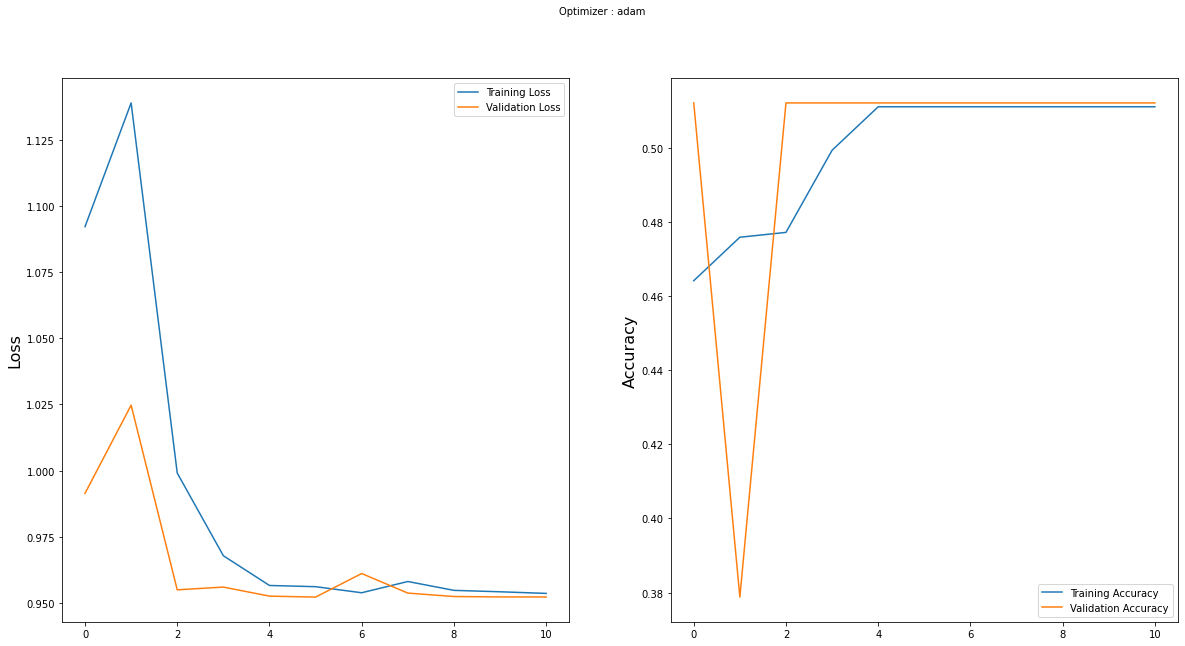

In [43]:
import matplotlib.pyplot as plt

x=hist1
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# DenseNet201

In [44]:
from tensorflow.keras.applications import DenseNet169, DenseNet201

In [45]:
des169=DenseNet169(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)
x1= Flatten()(des169.output)
prediction1 = Dense(3, activation='softmax')(x1)
model2 = Model(inputs = des169.inputs, outputs = prediction1)
model2.summary()
model2.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_5"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_7 (InputLayer)            [(None, 128, 128, 3) 0                                            
__________________________________________________________________________________________________
zero_padding2d_2 (ZeroPadding2D (None, 134, 134, 3)  0           input_7[0][0]                    
__________________________________________________________________________________________________
conv1/conv (Conv2D)             (None, 64, 64, 64)   9408        zero_padding2d_2[0][0]           
__________________________________________________________________________________________________
conv1/bn (BatchNormalization)   (None, 64, 64, 64)   256         conv1/conv[0][0]                 
____________________________________________________________________________________________

conv3_block4_1_conv (Conv2D)    (None, 16, 16, 128)  28672       conv3_block4_0_relu[0][0]        
__________________________________________________________________________________________________
conv3_block4_1_bn (BatchNormali (None, 16, 16, 128)  512         conv3_block4_1_conv[0][0]        
__________________________________________________________________________________________________
conv3_block4_1_relu (Activation (None, 16, 16, 128)  0           conv3_block4_1_bn[0][0]          
__________________________________________________________________________________________________
conv3_block4_2_conv (Conv2D)    (None, 16, 16, 32)   36864       conv3_block4_1_relu[0][0]        
__________________________________________________________________________________________________
conv3_block4_concat (Concatenat (None, 16, 16, 256)  0           conv3_block3_concat[0][0]        
                                                                 conv3_block4_2_conv[0][0]        
__________

conv4_block2_2_conv (Conv2D)    (None, 8, 8, 32)     36864       conv4_block2_1_relu[0][0]        
__________________________________________________________________________________________________
conv4_block2_concat (Concatenat (None, 8, 8, 320)    0           conv4_block1_concat[0][0]        
                                                                 conv4_block2_2_conv[0][0]        
__________________________________________________________________________________________________
conv4_block3_0_bn (BatchNormali (None, 8, 8, 320)    1280        conv4_block2_concat[0][0]        
__________________________________________________________________________________________________
conv4_block3_0_relu (Activation (None, 8, 8, 320)    0           conv4_block3_0_bn[0][0]          
__________________________________________________________________________________________________
conv4_block3_1_conv (Conv2D)    (None, 8, 8, 128)    40960       conv4_block3_0_relu[0][0]        
__________

__________________________________________________________________________________________________
conv4_block13_2_conv (Conv2D)   (None, 8, 8, 32)     36864       conv4_block13_1_relu[0][0]       
__________________________________________________________________________________________________
conv4_block13_concat (Concatena (None, 8, 8, 672)    0           conv4_block12_concat[0][0]       
                                                                 conv4_block13_2_conv[0][0]       
__________________________________________________________________________________________________
conv4_block14_0_bn (BatchNormal (None, 8, 8, 672)    2688        conv4_block13_concat[0][0]       
__________________________________________________________________________________________________
conv4_block14_0_relu (Activatio (None, 8, 8, 672)    0           conv4_block14_0_bn[0][0]         
__________________________________________________________________________________________________
conv4_bloc

conv4_block24_1_relu (Activatio (None, 8, 8, 128)    0           conv4_block24_1_bn[0][0]         
__________________________________________________________________________________________________
conv4_block24_2_conv (Conv2D)   (None, 8, 8, 32)     36864       conv4_block24_1_relu[0][0]       
__________________________________________________________________________________________________
conv4_block24_concat (Concatena (None, 8, 8, 1024)   0           conv4_block23_concat[0][0]       
                                                                 conv4_block24_2_conv[0][0]       
__________________________________________________________________________________________________
conv4_block25_0_bn (BatchNormal (None, 8, 8, 1024)   4096        conv4_block24_concat[0][0]       
__________________________________________________________________________________________________
conv4_block25_0_relu (Activatio (None, 8, 8, 1024)   0           conv4_block25_0_bn[0][0]         
__________

__________________________________________________________________________________________________
conv5_block3_0_bn (BatchNormali (None, 4, 4, 704)    2816        conv5_block2_concat[0][0]        
__________________________________________________________________________________________________
conv5_block3_0_relu (Activation (None, 4, 4, 704)    0           conv5_block3_0_bn[0][0]          
__________________________________________________________________________________________________
conv5_block3_1_conv (Conv2D)    (None, 4, 4, 128)    90112       conv5_block3_0_relu[0][0]        
__________________________________________________________________________________________________
conv5_block3_1_bn (BatchNormali (None, 4, 4, 128)    512         conv5_block3_1_conv[0][0]        
__________________________________________________________________________________________________
conv5_block3_1_relu (Activation (None, 4, 4, 128)    0           conv5_block3_1_bn[0][0]          
__________

                                                                 conv5_block13_2_conv[0][0]       
__________________________________________________________________________________________________
conv5_block14_0_bn (BatchNormal (None, 4, 4, 1056)   4224        conv5_block13_concat[0][0]       
__________________________________________________________________________________________________
conv5_block14_0_relu (Activatio (None, 4, 4, 1056)   0           conv5_block14_0_bn[0][0]         
__________________________________________________________________________________________________
conv5_block14_1_conv (Conv2D)   (None, 4, 4, 128)    135168      conv5_block14_0_relu[0][0]       
__________________________________________________________________________________________________
conv5_block14_1_bn (BatchNormal (None, 4, 4, 128)    512         conv5_block14_1_conv[0][0]       
__________________________________________________________________________________________________
conv5_bloc

conv5_block24_concat (Concatena (None, 4, 4, 1408)   0           conv5_block23_concat[0][0]       
                                                                 conv5_block24_2_conv[0][0]       
__________________________________________________________________________________________________
conv5_block25_0_bn (BatchNormal (None, 4, 4, 1408)   5632        conv5_block24_concat[0][0]       
__________________________________________________________________________________________________
conv5_block25_0_relu (Activatio (None, 4, 4, 1408)   0           conv5_block25_0_bn[0][0]         
__________________________________________________________________________________________________
conv5_block25_1_conv (Conv2D)   (None, 4, 4, 128)    180224      conv5_block25_0_relu[0][0]       
__________________________________________________________________________________________________
conv5_block25_1_bn (BatchNormal (None, 4, 4, 128)    512         conv5_block25_1_conv[0][0]       
__________

In [47]:
hist2 = model2.fit(train_set, validation_data=test_set, epochs=20, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/20


 82/384 [=====>........................] - ETA: 1:32:32 - loss: 1.6938 - accuracy: 0.5000 - f1_m: 0.5000 - precision_m: 0.5000 - recall_m: 0.500 - ETA: 2:30 - loss: 6.5258 - accuracy: 0.5000 - f1_m: 0.5000 - precision_m: 0.5000 - recall_m: 0.5000  - ETA: 2:29 - loss: 8.1984 - accuracy: 0.5000 - f1_m: 0.5000 - precision_m: 0.5000 - recall_m: 0.50 - ETA: 2:28 - loss: 8.3013 - accuracy: 0.3750 - f1_m: 0.3750 - precision_m: 0.3750 - recall_m: 0.37 - ETA: 2:24 - loss: 10.6648 - accuracy: 0.3000 - f1_m: 0.3000 - precision_m: 0.3000 - recall_m: 0.300 - ETA: 2:22 - loss: 9.5889 - accuracy: 0.3333 - f1_m: 0.3333 - precision_m: 0.3333 - recall_m: 0.333 - ETA: 2:24 - loss: 8.2191 - accuracy: 0.4286 - f1_m: 0.4286 - precision_m: 0.4286 - recall_m: 0.42 - ETA: 2:23 - loss: 8.4092 - accuracy: 0.4375 - f1_m: 0.4375 - precision_m: 0.4375 - recall_m: 0.43 - ETA: 2:22 - loss: 10.4448 - accuracy: 0.3889 - f1_m: 0.3889 - precision_m: 0.3889 - recall_m: 0.388 - ETA: 2:21 - loss: 9.9071 - accuracy: 0.4000 -

246/384 [==================>...........] - ETA: 1:35 - loss: 5.8691 - accuracy: 0.4333 - f1_m: 0.4293 - precision_m: 0.4333 - recall_m: 0.42 - ETA: 1:35 - loss: 5.9515 - accuracy: 0.4337 - f1_m: 0.4297 - precision_m: 0.4337 - recall_m: 0.42 - ETA: 1:35 - loss: 5.9294 - accuracy: 0.4311 - f1_m: 0.4271 - precision_m: 0.4311 - recall_m: 0.42 - ETA: 1:35 - loss: 5.8992 - accuracy: 0.4315 - f1_m: 0.4276 - precision_m: 0.4315 - recall_m: 0.42 - ETA: 1:34 - loss: 5.9261 - accuracy: 0.4320 - f1_m: 0.4280 - precision_m: 0.4320 - recall_m: 0.42 - ETA: 1:34 - loss: 5.9242 - accuracy: 0.4294 - f1_m: 0.4255 - precision_m: 0.4294 - recall_m: 0.42 - ETA: 1:34 - loss: 6.0505 - accuracy: 0.4269 - f1_m: 0.4230 - precision_m: 0.4269 - recall_m: 0.42 - ETA: 1:33 - loss: 6.0434 - accuracy: 0.4273 - f1_m: 0.4234 - precision_m: 0.4273 - recall_m: 0.42 - ETA: 1:33 - loss: 6.0461 - accuracy: 0.4277 - f1_m: 0.4239 - precision_m: 0.4277 - recall_m: 0.42 - ETA: 1:33 - loss: 6.0389 - accuracy: 0.4282 - f1_m: 0.424

328/384 [========================>.....] - ETA: 1:05 - loss: 5.6988 - accuracy: 0.4312 - f1_m: 0.4285 - precision_m: 0.4312 - recall_m: 0.42 - ETA: 1:05 - loss: 5.7096 - accuracy: 0.4315 - f1_m: 0.4288 - precision_m: 0.4315 - recall_m: 0.42 - ETA: 1:04 - loss: 5.7221 - accuracy: 0.4297 - f1_m: 0.4270 - precision_m: 0.4297 - recall_m: 0.42 - ETA: 1:04 - loss: 5.7147 - accuracy: 0.4300 - f1_m: 0.4273 - precision_m: 0.4300 - recall_m: 0.42 - ETA: 1:03 - loss: 5.6921 - accuracy: 0.4323 - f1_m: 0.4296 - precision_m: 0.4323 - recall_m: 0.42 - ETA: 1:03 - loss: 5.6923 - accuracy: 0.4325 - f1_m: 0.4299 - precision_m: 0.4325 - recall_m: 0.42 - ETA: 1:02 - loss: 5.6698 - accuracy: 0.4348 - f1_m: 0.4321 - precision_m: 0.4348 - recall_m: 0.43 - ETA: 1:02 - loss: 5.6844 - accuracy: 0.4350 - f1_m: 0.4324 - precision_m: 0.4350 - recall_m: 0.43 - ETA: 1:01 - loss: 5.7203 - accuracy: 0.4333 - f1_m: 0.4307 - precision_m: 0.4333 - recall_m: 0.42 - ETA: 1:01 - loss: 5.6991 - accuracy: 0.4355 - f1_m: 0.432

384/384 [==============================] - ETA: 27s - loss: 5.8276 - accuracy: 0.4384 - f1_m: 0.4347 - precision_m: 0.4377 - recall_m: 0.433 - ETA: 26s - loss: 5.8372 - accuracy: 0.4385 - f1_m: 0.4348 - precision_m: 0.4379 - recall_m: 0.433 - ETA: 26s - loss: 5.8217 - accuracy: 0.4387 - f1_m: 0.4350 - precision_m: 0.4381 - recall_m: 0.433 - ETA: 25s - loss: 5.8184 - accuracy: 0.4389 - f1_m: 0.4352 - precision_m: 0.4383 - recall_m: 0.433 - ETA: 25s - loss: 5.8009 - accuracy: 0.4406 - f1_m: 0.4369 - precision_m: 0.4399 - recall_m: 0.435 - ETA: 24s - loss: 5.7836 - accuracy: 0.4423 - f1_m: 0.4386 - precision_m: 0.4416 - recall_m: 0.437 - ETA: 24s - loss: 5.7675 - accuracy: 0.4425 - f1_m: 0.4388 - precision_m: 0.4418 - recall_m: 0.437 - ETA: 23s - loss: 5.8072 - accuracy: 0.4411 - f1_m: 0.4375 - precision_m: 0.4405 - recall_m: 0.436 - ETA: 23s - loss: 5.8081 - accuracy: 0.4413 - f1_m: 0.4377 - precision_m: 0.4407 - recall_m: 0.436 - ETA: 22s - loss: 5.7910 - accuracy: 0.4430 - f1_m: 0.4393

...

384/384 [==============================] - ETA: 30s - loss: 0.2980 - accuracy: 0.8767 - f1_m: 0.8734 - precision_m: 0.8784 - recall_m: 0.870 - ETA: 30s - loss: 0.2976 - accuracy: 0.8771 - f1_m: 0.8737 - precision_m: 0.8788 - recall_m: 0.871 - ETA: 29s - loss: 0.2967 - accuracy: 0.8775 - f1_m: 0.8741 - precision_m: 0.8792 - recall_m: 0.871 - ETA: 29s - loss: 0.2969 - accuracy: 0.8763 - f1_m: 0.8730 - precision_m: 0.8780 - recall_m: 0.870 - ETA: 28s - loss: 0.2961 - accuracy: 0.8767 - f1_m: 0.8734 - precision_m: 0.8784 - recall_m: 0.870 - ETA: 28s - loss: 0.2991 - accuracy: 0.8756 - f1_m: 0.8723 - precision_m: 0.8772 - recall_m: 0.869 - ETA: 27s - loss: 0.2986 - accuracy: 0.8759 - f1_m: 0.8726 - precision_m: 0.8776 - recall_m: 0.870 - ETA: 26s - loss: 0.2977 - accuracy: 0.8763 - f1_m: 0.8730 - precision_m: 0.8780 - recall_m: 0.870 - ETA: 26s - loss: 0.2972 - accuracy: 0.8767 - f1_m: 0.8734 - precision_m: 0.8783 - recall_m: 0.870 - ETA: 25s - loss: 0.2965 - accuracy: 0.8770 - f1_m: 0.8738

 82/384 [=====>........................] - ETA: 4:24 - loss: 0.2227 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 3:55 - loss: 0.1215 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 3:47 - loss: 0.0828 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 3:58 - loss: 0.0649 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 3:42 - loss: 0.0834 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 3:44 - loss: 0.0732 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 3:44 - loss: 0.1253 - accuracy: 0.9286 - f1_m: 0.9286 - precision_m: 0.9286 - recall_m: 0.92 - ETA: 3:39 - loss: 0.1328 - accuracy: 0.9375 - f1_m: 0.9375 - precision_m: 0.9375 - recall_m: 0.93 - ETA: 3:35 - loss: 0.1388 - accuracy: 0.9444 - f1_m: 0.9444 - precision_m: 0.9444 - recall_m: 0.94 - ETA: 3:32 - loss: 0.1250 - accuracy: 0.9500 - f1_m: 0.950

246/384 [==================>...........] - ETA: 2:02 - loss: 0.2456 - accuracy: 0.9121 - f1_m: 0.9101 - precision_m: 0.9182 - recall_m: 0.90 - ETA: 2:02 - loss: 0.2442 - accuracy: 0.9127 - f1_m: 0.9106 - precision_m: 0.9187 - recall_m: 0.90 - ETA: 2:01 - loss: 0.2501 - accuracy: 0.9102 - f1_m: 0.9082 - precision_m: 0.9162 - recall_m: 0.90 - ETA: 2:00 - loss: 0.2486 - accuracy: 0.9107 - f1_m: 0.9087 - precision_m: 0.9167 - recall_m: 0.90 - ETA: 2:00 - loss: 0.2478 - accuracy: 0.9112 - f1_m: 0.9093 - precision_m: 0.9172 - recall_m: 0.90 - ETA: 1:59 - loss: 0.2466 - accuracy: 0.9118 - f1_m: 0.9098 - precision_m: 0.9176 - recall_m: 0.90 - ETA: 1:59 - loss: 0.2483 - accuracy: 0.9094 - f1_m: 0.9074 - precision_m: 0.9152 - recall_m: 0.90 - ETA: 1:58 - loss: 0.2470 - accuracy: 0.9099 - f1_m: 0.9079 - precision_m: 0.9157 - recall_m: 0.90 - ETA: 1:58 - loss: 0.2457 - accuracy: 0.9104 - f1_m: 0.9085 - precision_m: 0.9162 - recall_m: 0.90 - ETA: 1:57 - loss: 0.2449 - accuracy: 0.9109 - f1_m: 0.909

328/384 [========================>.....] - ETA: 1:16 - loss: 0.2584 - accuracy: 0.9026 - f1_m: 0.8981 - precision_m: 0.9089 - recall_m: 0.89 - ETA: 1:16 - loss: 0.2575 - accuracy: 0.9030 - f1_m: 0.8985 - precision_m: 0.9093 - recall_m: 0.89 - ETA: 1:15 - loss: 0.2565 - accuracy: 0.9034 - f1_m: 0.8989 - precision_m: 0.9096 - recall_m: 0.89 - ETA: 1:15 - loss: 0.2555 - accuracy: 0.9038 - f1_m: 0.8993 - precision_m: 0.9100 - recall_m: 0.89 - ETA: 1:14 - loss: 0.2546 - accuracy: 0.9042 - f1_m: 0.8997 - precision_m: 0.9104 - recall_m: 0.89 - ETA: 1:14 - loss: 0.2537 - accuracy: 0.9046 - f1_m: 0.9001 - precision_m: 0.9107 - recall_m: 0.89 - ETA: 1:13 - loss: 0.2528 - accuracy: 0.9050 - f1_m: 0.9005 - precision_m: 0.9111 - recall_m: 0.89 - ETA: 1:13 - loss: 0.2523 - accuracy: 0.9053 - f1_m: 0.9009 - precision_m: 0.9114 - recall_m: 0.89 - ETA: 1:12 - loss: 0.2516 - accuracy: 0.9057 - f1_m: 0.9013 - precision_m: 0.9118 - recall_m: 0.89 - ETA: 1:12 - loss: 0.2506 - accuracy: 0.9061 - f1_m: 0.901

384/384 [==============================] - ETA: 30s - loss: 0.2579 - accuracy: 0.9026 - f1_m: 0.8982 - precision_m: 0.9073 - recall_m: 0.893 - ETA: 30s - loss: 0.2577 - accuracy: 0.9029 - f1_m: 0.8985 - precision_m: 0.9076 - recall_m: 0.893 - ETA: 29s - loss: 0.2572 - accuracy: 0.9032 - f1_m: 0.8988 - precision_m: 0.9079 - recall_m: 0.894 - ETA: 29s - loss: 0.2565 - accuracy: 0.9035 - f1_m: 0.8991 - precision_m: 0.9081 - recall_m: 0.894 - ETA: 28s - loss: 0.2558 - accuracy: 0.9038 - f1_m: 0.8994 - precision_m: 0.9084 - recall_m: 0.894 - ETA: 28s - loss: 0.2551 - accuracy: 0.9040 - f1_m: 0.8997 - precision_m: 0.9087 - recall_m: 0.895 - ETA: 27s - loss: 0.2543 - accuracy: 0.9043 - f1_m: 0.9000 - precision_m: 0.9090 - recall_m: 0.895 - ETA: 26s - loss: 0.2589 - accuracy: 0.9031 - f1_m: 0.8988 - precision_m: 0.9077 - recall_m: 0.894 - ETA: 26s - loss: 0.2581 - accuracy: 0.9034 - f1_m: 0.8991 - precision_m: 0.9080 - recall_m: 0.894 - ETA: 25s - loss: 0.2575 - accuracy: 0.9037 - f1_m: 0.8994

In [97]:
dense_acc = hist2.history["val_accuracy"][9]
dense_prec = hist2.history["val_precision_m"][9]
dense_rec = hist2.history["val_recall_m"][9]
dense_f1 = hist2.history["val_f1_m"][9]

In [103]:
storeResults('DenseNet201',dense_acc,dense_prec,dense_rec,dense_f1)

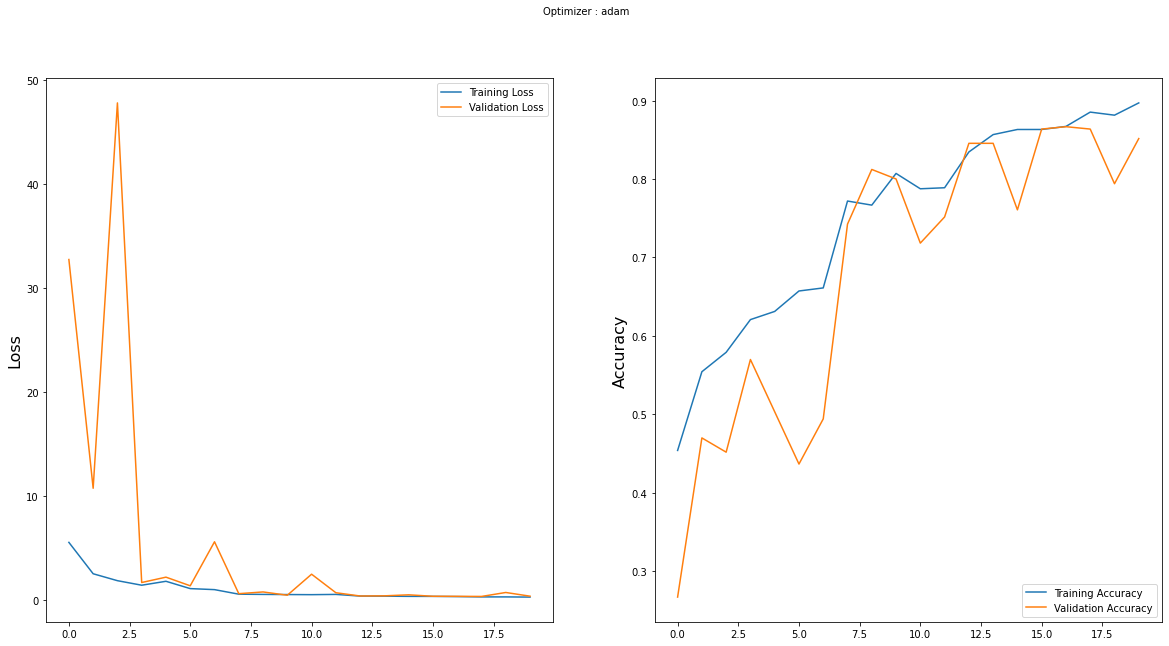

In [48]:
import matplotlib.pyplot as plt

x=hist2
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# EfficientNetB2

In [49]:
from tensorflow.keras.applications import EfficientNetB2

In [50]:
eff = EfficientNetB2(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)
x1= Flatten()(eff.output)
prediction1 = Dense(3, activation='softmax')(x1)
model3 = Model(inputs = eff.inputs, outputs = prediction1)
model3.summary()
model3.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_6"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_8 (InputLayer)            [(None, 128, 128, 3) 0                                            
__________________________________________________________________________________________________
rescaling_1 (Rescaling)         (None, 128, 128, 3)  0           input_8[0][0]                    
__________________________________________________________________________________________________
normalization_1 (Normalization) (None, 128, 128, 3)  7           rescaling_1[0][0]                
__________________________________________________________________________________________________
stem_conv_pad (ZeroPadding2D)   (None, 129, 129, 3)  0           normalization_1[0][0]            
____________________________________________________________________________________________

__________________________________________________________________________________________________
block3a_dwconv (DepthwiseConv2D (None, 16, 16, 144)  3600        block3a_dwconv_pad[0][0]         
__________________________________________________________________________________________________
block3a_bn (BatchNormalization) (None, 16, 16, 144)  576         block3a_dwconv[0][0]             
__________________________________________________________________________________________________
block3a_activation (Activation) (None, 16, 16, 144)  0           block3a_bn[0][0]                 
__________________________________________________________________________________________________
block3a_se_squeeze (GlobalAvera (None, 144)          0           block3a_activation[0][0]         
__________________________________________________________________________________________________
block3a_se_reshape (Reshape)    (None, 1, 1, 144)    0           block3a_se_squeeze[0][0]         
__________

__________________________________________________________________________________________________
block4c_se_expand (Conv2D)      (None, 1, 1, 528)    12144       block4c_se_reduce[0][0]          
__________________________________________________________________________________________________
block4c_se_excite (Multiply)    (None, 8, 8, 528)    0           block4c_activation[0][0]         
                                                                 block4c_se_expand[0][0]          
__________________________________________________________________________________________________
block4c_project_conv (Conv2D)   (None, 8, 8, 88)     46464       block4c_se_excite[0][0]          
__________________________________________________________________________________________________
block4c_project_bn (BatchNormal (None, 8, 8, 88)     352         block4c_project_conv[0][0]       
__________________________________________________________________________________________________
block4c_dr

__________________________________________________________________________________________________
block5d_drop (Dropout)          (None, 8, 8, 120)    0           block5d_project_bn[0][0]         
__________________________________________________________________________________________________
block5d_add (Add)               (None, 8, 8, 120)    0           block5d_drop[0][0]               
                                                                 block5c_add[0][0]                
__________________________________________________________________________________________________
block6a_expand_conv (Conv2D)    (None, 8, 8, 720)    86400       block5d_add[0][0]                
__________________________________________________________________________________________________
block6a_expand_bn (BatchNormali (None, 8, 8, 720)    2880        block6a_expand_conv[0][0]        
__________________________________________________________________________________________________
block6a_ex

__________________________________________________________________________________________________
block7a_expand_bn (BatchNormali (None, 4, 4, 1248)   4992        block7a_expand_conv[0][0]        
__________________________________________________________________________________________________
block7a_expand_activation (Acti (None, 4, 4, 1248)   0           block7a_expand_bn[0][0]          
__________________________________________________________________________________________________
block7a_dwconv (DepthwiseConv2D (None, 4, 4, 1248)   11232       block7a_expand_activation[0][0]  
__________________________________________________________________________________________________
block7a_bn (BatchNormalization) (None, 4, 4, 1248)   4992        block7a_dwconv[0][0]             
__________________________________________________________________________________________________
block7a_activation (Activation) (None, 4, 4, 1248)   0           block7a_bn[0][0]                 
__________

In [51]:
hist3 = model3.fit(train_set, validation_data=test_set, epochs=20, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/20


 81/384 [=====>........................] - ETA: 1:14:46 - loss: 2.1383 - accuracy: 0.0000e+00 - f1_m: 0.0000e+00 - precision_m: 0.0000e+00 - recall_m: 0.0000e+0 - ETA: 1:18 - loss: 7.0334 - accuracy: 0.0000e+00 - f1_m: 0.0000e+00 - precision_m: 0.0000e+00 - recall_m: 0.0000e+00  - ETA: 1:28 - loss: 5.6314 - accuracy: 0.1667 - f1_m: 0.1667 - precision_m: 0.1667 - recall_m: 0.1667               - ETA: 1:29 - loss: 4.7961 - accuracy: 0.2500 - f1_m: 0.2500 - precision_m: 0.2500 - recall_m: 0.25 - ETA: 1:31 - loss: 4.0698 - accuracy: 0.3000 - f1_m: 0.3000 - precision_m: 0.3000 - recall_m: 0.30 - ETA: 1:36 - loss: 3.8874 - accuracy: 0.2500 - f1_m: 0.2500 - precision_m: 0.2500 - recall_m: 0.25 - ETA: 1:38 - loss: 4.2942 - accuracy: 0.2857 - f1_m: 0.2857 - precision_m: 0.2857 - recall_m: 0.28 - ETA: 1:40 - loss: 4.0335 - accuracy: 0.3125 - f1_m: 0.3125 - precision_m: 0.3125 - recall_m: 0.31 - ETA: 1:42 - loss: 3.5854 - accuracy: 0.3889 - f1_m: 0.3889 - precision_m: 0.3889 - recall_m: 0.38 - ET

245/384 [==================>...........] - ETA: 1:03 - loss: 2.3772 - accuracy: 0.5793 - f1_m: 0.5783 - precision_m: 0.5884 - recall_m: 0.57 - ETA: 1:03 - loss: 2.3914 - accuracy: 0.5788 - f1_m: 0.5778 - precision_m: 0.5879 - recall_m: 0.57 - ETA: 1:03 - loss: 2.3906 - accuracy: 0.5783 - f1_m: 0.5773 - precision_m: 0.5873 - recall_m: 0.57 - ETA: 1:02 - loss: 2.3966 - accuracy: 0.5749 - f1_m: 0.5739 - precision_m: 0.5838 - recall_m: 0.56 - ETA: 1:02 - loss: 2.3887 - accuracy: 0.5744 - f1_m: 0.5734 - precision_m: 0.5833 - recall_m: 0.56 - ETA: 1:02 - loss: 2.3774 - accuracy: 0.5740 - f1_m: 0.5730 - precision_m: 0.5828 - recall_m: 0.56 - ETA: 1:01 - loss: 2.3739 - accuracy: 0.5735 - f1_m: 0.5725 - precision_m: 0.5824 - recall_m: 0.56 - ETA: 1:01 - loss: 2.3996 - accuracy: 0.5702 - f1_m: 0.5692 - precision_m: 0.5789 - recall_m: 0.56 - ETA: 1:01 - loss: 2.3885 - accuracy: 0.5698 - f1_m: 0.5688 - precision_m: 0.5785 - recall_m: 0.56 - ETA: 1:01 - loss: 2.3748 - accuracy: 0.5723 - f1_m: 0.571

327/384 [========================>.....] - ETA: 40s - loss: 2.1161 - accuracy: 0.5976 - f1_m: 0.5969 - precision_m: 0.6037 - recall_m: 0.593 - ETA: 39s - loss: 2.1076 - accuracy: 0.5992 - f1_m: 0.5985 - precision_m: 0.6053 - recall_m: 0.595 - ETA: 39s - loss: 2.1167 - accuracy: 0.5968 - f1_m: 0.5961 - precision_m: 0.6028 - recall_m: 0.592 - ETA: 39s - loss: 2.1135 - accuracy: 0.5964 - f1_m: 0.5957 - precision_m: 0.6024 - recall_m: 0.592 - ETA: 39s - loss: 2.1119 - accuracy: 0.5940 - f1_m: 0.5933 - precision_m: 0.6000 - recall_m: 0.590 - ETA: 38s - loss: 2.1115 - accuracy: 0.5936 - f1_m: 0.5930 - precision_m: 0.5996 - recall_m: 0.589 - ETA: 38s - loss: 2.1056 - accuracy: 0.5933 - f1_m: 0.5933 - precision_m: 0.6012 - recall_m: 0.589 - ETA: 38s - loss: 2.1016 - accuracy: 0.5929 - f1_m: 0.5929 - precision_m: 0.6008 - recall_m: 0.588 - ETA: 37s - loss: 2.0940 - accuracy: 0.5945 - f1_m: 0.5945 - precision_m: 0.6024 - recall_m: 0.590 - ETA: 37s - loss: 2.0869 - accuracy: 0.5961 - f1_m: 0.5961

384/384 [==============================] - ETA: 16s - loss: 1.9952 - accuracy: 0.6006 - f1_m: 0.6021 - precision_m: 0.6113 - recall_m: 0.597 - ETA: 16s - loss: 1.9902 - accuracy: 0.6018 - f1_m: 0.6033 - precision_m: 0.6125 - recall_m: 0.598 - ETA: 15s - loss: 1.9842 - accuracy: 0.6030 - f1_m: 0.6045 - precision_m: 0.6136 - recall_m: 0.600 - ETA: 15s - loss: 1.9784 - accuracy: 0.6042 - f1_m: 0.6057 - precision_m: 0.6148 - recall_m: 0.601 - ETA: 15s - loss: 1.9823 - accuracy: 0.6039 - f1_m: 0.6054 - precision_m: 0.6145 - recall_m: 0.600 - ETA: 15s - loss: 1.9766 - accuracy: 0.6051 - f1_m: 0.6066 - precision_m: 0.6156 - recall_m: 0.602 - ETA: 14s - loss: 1.9735 - accuracy: 0.6048 - f1_m: 0.6063 - precision_m: 0.6153 - recall_m: 0.601 - ETA: 14s - loss: 1.9756 - accuracy: 0.6045 - f1_m: 0.6060 - precision_m: 0.6149 - recall_m: 0.601 - ETA: 14s - loss: 1.9704 - accuracy: 0.6057 - f1_m: 0.6071 - precision_m: 0.6161 - recall_m: 0.602 - ETA: 13s - loss: 1.9727 - accuracy: 0.6053 - f1_m: 0.6068

...

384/384 [==============================] - ETA: 16s - loss: 0.0469 - accuracy: 0.9848 - f1_m: 0.9848 - precision_m: 0.9848 - recall_m: 0.984 - ETA: 16s - loss: 0.0467 - accuracy: 0.9848 - f1_m: 0.9848 - precision_m: 0.9848 - recall_m: 0.984 - ETA: 15s - loss: 0.0466 - accuracy: 0.9849 - f1_m: 0.9849 - precision_m: 0.9849 - recall_m: 0.984 - ETA: 15s - loss: 0.0465 - accuracy: 0.9849 - f1_m: 0.9849 - precision_m: 0.9849 - recall_m: 0.984 - ETA: 15s - loss: 0.0466 - accuracy: 0.9850 - f1_m: 0.9850 - precision_m: 0.9850 - recall_m: 0.985 - ETA: 14s - loss: 0.0465 - accuracy: 0.9850 - f1_m: 0.9850 - precision_m: 0.9850 - recall_m: 0.985 - ETA: 14s - loss: 0.0464 - accuracy: 0.9851 - f1_m: 0.9851 - precision_m: 0.9851 - recall_m: 0.985 - ETA: 14s - loss: 0.0463 - accuracy: 0.9851 - f1_m: 0.9851 - precision_m: 0.9851 - recall_m: 0.985 - ETA: 14s - loss: 0.0462 - accuracy: 0.9851 - f1_m: 0.9852 - precision_m: 0.9852 - recall_m: 0.985 - ETA: 13s - loss: 0.0461 - accuracy: 0.9852 - f1_m: 0.9852

 82/384 [=====>........................] - ETA: 1:24 - loss: 0.0133 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:36 - loss: 0.0828 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:39 - loss: 0.0680 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:41 - loss: 0.0557 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:42 - loss: 0.0446 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:43 - loss: 0.0375 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:43 - loss: 0.0322 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:45 - loss: 0.0283 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:46 - loss: 0.0255 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:44 - loss: 0.0230 - accuracy: 1.0000 - f1_m: 1.000

246/384 [==================>...........] - ETA: 1:04 - loss: 0.0189 - accuracy: 0.9939 - f1_m: 0.9939 - precision_m: 0.9939 - recall_m: 0.99 - ETA: 1:04 - loss: 0.0276 - accuracy: 0.9910 - f1_m: 0.9910 - precision_m: 0.9910 - recall_m: 0.99 - ETA: 1:03 - loss: 0.0274 - accuracy: 0.9910 - f1_m: 0.9910 - precision_m: 0.9910 - recall_m: 0.99 - ETA: 1:03 - loss: 0.0273 - accuracy: 0.9911 - f1_m: 0.9911 - precision_m: 0.9911 - recall_m: 0.99 - ETA: 1:03 - loss: 0.0272 - accuracy: 0.9911 - f1_m: 0.9911 - precision_m: 0.9911 - recall_m: 0.99 - ETA: 1:02 - loss: 0.0271 - accuracy: 0.9912 - f1_m: 0.9912 - precision_m: 0.9912 - recall_m: 0.99 - ETA: 1:02 - loss: 0.0273 - accuracy: 0.9912 - f1_m: 0.9912 - precision_m: 0.9912 - recall_m: 0.99 - ETA: 1:02 - loss: 0.0272 - accuracy: 0.9913 - f1_m: 0.9913 - precision_m: 0.9913 - recall_m: 0.99 - ETA: 1:02 - loss: 0.0278 - accuracy: 0.9913 - f1_m: 0.9913 - precision_m: 0.9913 - recall_m: 0.99 - ETA: 1:01 - loss: 0.0276 - accuracy: 0.9914 - f1_m: 0.991

328/384 [========================>.....] - ETA: 40s - loss: 0.0359 - accuracy: 0.9878 - f1_m: 0.9879 - precision_m: 0.9879 - recall_m: 0.987 - ETA: 40s - loss: 0.0409 - accuracy: 0.9859 - f1_m: 0.9859 - precision_m: 0.9859 - recall_m: 0.985 - ETA: 39s - loss: 0.0408 - accuracy: 0.9859 - f1_m: 0.9859 - precision_m: 0.9859 - recall_m: 0.985 - ETA: 39s - loss: 0.0406 - accuracy: 0.9860 - f1_m: 0.9860 - precision_m: 0.9860 - recall_m: 0.986 - ETA: 39s - loss: 0.0405 - accuracy: 0.9860 - f1_m: 0.9861 - precision_m: 0.9861 - recall_m: 0.986 - ETA: 38s - loss: 0.0403 - accuracy: 0.9861 - f1_m: 0.9861 - precision_m: 0.9861 - recall_m: 0.986 - ETA: 38s - loss: 0.0401 - accuracy: 0.9861 - f1_m: 0.9862 - precision_m: 0.9862 - recall_m: 0.986 - ETA: 38s - loss: 0.0400 - accuracy: 0.9862 - f1_m: 0.9862 - precision_m: 0.9862 - recall_m: 0.986 - ETA: 37s - loss: 0.0398 - accuracy: 0.9862 - f1_m: 0.9863 - precision_m: 0.9863 - recall_m: 0.986 - ETA: 37s - loss: 0.0401 - accuracy: 0.9863 - f1_m: 0.9863

384/384 [==============================] - ETA: 16s - loss: 0.0399 - accuracy: 0.9848 - f1_m: 0.9848 - precision_m: 0.9848 - recall_m: 0.984 - ETA: 15s - loss: 0.0398 - accuracy: 0.9848 - f1_m: 0.9848 - precision_m: 0.9848 - recall_m: 0.984 - ETA: 15s - loss: 0.0397 - accuracy: 0.9849 - f1_m: 0.9849 - precision_m: 0.9849 - recall_m: 0.984 - ETA: 15s - loss: 0.0396 - accuracy: 0.9849 - f1_m: 0.9849 - precision_m: 0.9849 - recall_m: 0.984 - ETA: 15s - loss: 0.0394 - accuracy: 0.9850 - f1_m: 0.9850 - precision_m: 0.9850 - recall_m: 0.985 - ETA: 14s - loss: 0.0394 - accuracy: 0.9850 - f1_m: 0.9850 - precision_m: 0.9850 - recall_m: 0.985 - ETA: 14s - loss: 0.0393 - accuracy: 0.9851 - f1_m: 0.9851 - precision_m: 0.9851 - recall_m: 0.985 - ETA: 14s - loss: 0.0392 - accuracy: 0.9851 - f1_m: 0.9851 - precision_m: 0.9851 - recall_m: 0.985 - ETA: 13s - loss: 0.0391 - accuracy: 0.9851 - f1_m: 0.9852 - precision_m: 0.9852 - recall_m: 0.985 - ETA: 13s - loss: 0.0390 - accuracy: 0.9852 - f1_m: 0.9852

In [98]:
eff_acc = hist3.history["val_accuracy"][19]
eff_prec = hist3.history["val_precision_m"][19]
eff_rec = hist3.history["val_recall_m"][19]
eff_f1 = hist3.history["val_f1_m"][19]

In [104]:
storeResults('EfficientNetB2',eff_acc,eff_prec,eff_rec,eff_f1)

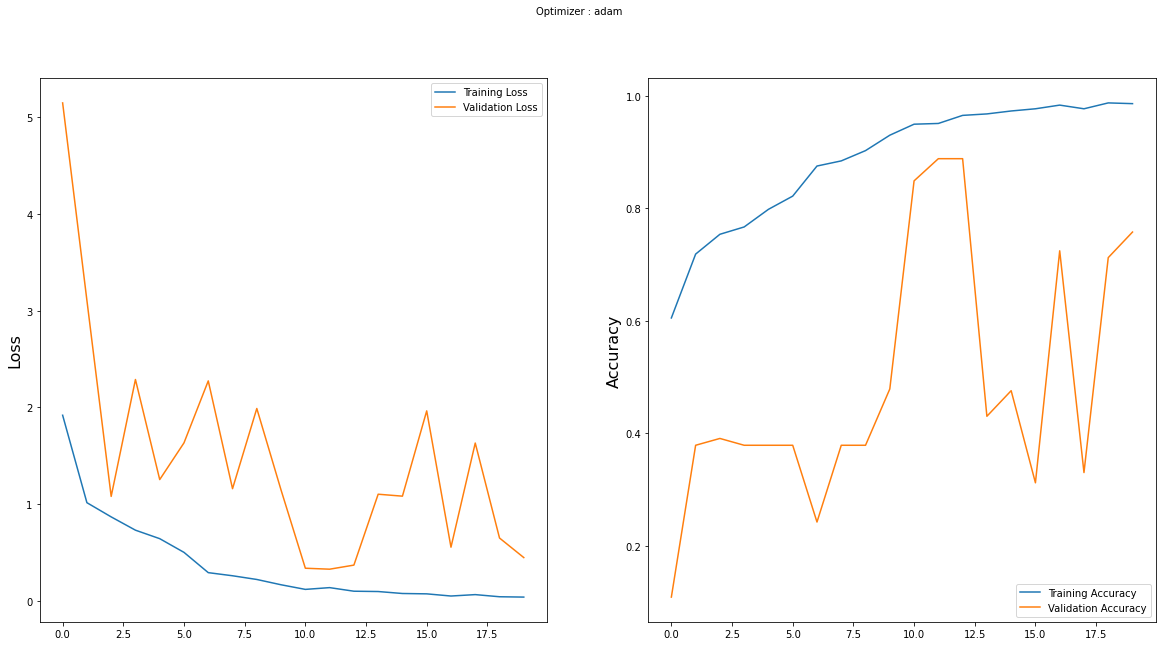

In [52]:
import matplotlib.pyplot as plt

x=hist3
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# ResNet101

In [53]:
from tensorflow.keras.applications import ResNet101

res101V2=ResNet101(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [54]:
x1= Flatten()(res101V2.output)
prediction1 = Dense(3, activation='softmax')(x1)
model4 = Model(inputs = res101V2.inputs, outputs = prediction1)
model4.summary()
model4.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_7"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_9 (InputLayer)            [(None, 128, 128, 3) 0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 134, 134, 3)  0           input_9[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 64, 64, 64)   9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
conv1_bn (BatchNormalization)   (None, 64, 64, 64)   256         conv1_conv[0][0]                 
____________________________________________________________________________________________

__________________________________________________________________________________________________
conv3_block4_3_bn (BatchNormali (None, 16, 16, 512)  2048        conv3_block4_3_conv[0][0]        
__________________________________________________________________________________________________
conv3_block4_add (Add)          (None, 16, 16, 512)  0           conv3_block3_out[0][0]           
                                                                 conv3_block4_3_bn[0][0]          
__________________________________________________________________________________________________
conv3_block4_out (Activation)   (None, 16, 16, 512)  0           conv3_block4_add[0][0]           
__________________________________________________________________________________________________
conv4_block1_1_conv (Conv2D)    (None, 8, 8, 256)    131328      conv3_block4_out[0][0]           
__________________________________________________________________________________________________
conv4_bloc

__________________________________________________________________________________________________
conv4_block8_2_conv (Conv2D)    (None, 8, 8, 256)    590080      conv4_block8_1_relu[0][0]        
__________________________________________________________________________________________________
conv4_block8_2_bn (BatchNormali (None, 8, 8, 256)    1024        conv4_block8_2_conv[0][0]        
__________________________________________________________________________________________________
conv4_block8_2_relu (Activation (None, 8, 8, 256)    0           conv4_block8_2_bn[0][0]          
__________________________________________________________________________________________________
conv4_block8_3_conv (Conv2D)    (None, 8, 8, 1024)   263168      conv4_block8_2_relu[0][0]        
__________________________________________________________________________________________________
conv4_block8_3_bn (BatchNormali (None, 8, 8, 1024)   4096        conv4_block8_3_conv[0][0]        
__________

__________________________________________________________________________________________________
conv4_block16_1_bn (BatchNormal (None, 8, 8, 256)    1024        conv4_block16_1_conv[0][0]       
__________________________________________________________________________________________________
conv4_block16_1_relu (Activatio (None, 8, 8, 256)    0           conv4_block16_1_bn[0][0]         
__________________________________________________________________________________________________
conv4_block16_2_conv (Conv2D)   (None, 8, 8, 256)    590080      conv4_block16_1_relu[0][0]       
__________________________________________________________________________________________________
conv4_block16_2_bn (BatchNormal (None, 8, 8, 256)    1024        conv4_block16_2_conv[0][0]       
__________________________________________________________________________________________________
conv4_block16_2_relu (Activatio (None, 8, 8, 256)    0           conv4_block16_2_bn[0][0]         
__________

__________________________________________________________________________________________________
conv4_block23_out (Activation)  (None, 8, 8, 1024)   0           conv4_block23_add[0][0]          
__________________________________________________________________________________________________
conv5_block1_1_conv (Conv2D)    (None, 4, 4, 512)    524800      conv4_block23_out[0][0]          
__________________________________________________________________________________________________
conv5_block1_1_bn (BatchNormali (None, 4, 4, 512)    2048        conv5_block1_1_conv[0][0]        
__________________________________________________________________________________________________
conv5_block1_1_relu (Activation (None, 4, 4, 512)    0           conv5_block1_1_bn[0][0]          
__________________________________________________________________________________________________
conv5_block1_2_conv (Conv2D)    (None, 4, 4, 512)    2359808     conv5_block1_1_relu[0][0]        
__________

In [55]:
hist4 = model4.fit(train_set, validation_data=test_set, epochs=20, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/20


 81/384 [=====>........................] - ETA: 1:09:49 - loss: 2.6726 - accuracy: 0.0000e+00 - f1_m: 0.0000e+00 - precision_m: 0.0000e+00 - recall_m: 0.0000e+0 - ETA: 3:15 - loss: 1.3363 - accuracy: 0.5000 - f1_m: 0.5000 - precision_m: 0.5000 - recall_m: 0.5000                  - ETA: 3:11 - loss: 14.2296 - accuracy: 0.3333 - f1_m: 0.3333 - precision_m: 0.3333 - recall_m: 0.333 - ETA: 3:13 - loss: 12.2471 - accuracy: 0.2500 - f1_m: 0.2500 - precision_m: 0.2500 - recall_m: 0.250 - ETA: 3:15 - loss: 12.1981 - accuracy: 0.3000 - f1_m: 0.3000 - precision_m: 0.3000 - recall_m: 0.300 - ETA: 3:24 - loss: 10.9741 - accuracy: 0.3333 - f1_m: 0.3333 - precision_m: 0.3333 - recall_m: 0.333 - ETA: 3:37 - loss: 10.8711 - accuracy: 0.3571 - f1_m: 0.3571 - precision_m: 0.3571 - recall_m: 0.357 - ETA: 3:49 - loss: 9.9202 - accuracy: 0.3750 - f1_m: 0.3750 - precision_m: 0.3750 - recall_m: 0.375 - ETA: 3:59 - loss: 9.2861 - accuracy: 0.3889 - f1_m: 0.3889 - precision_m: 0.3889 - recall_m: 0.38 - ETA: 4:

245/384 [==================>...........] - ETA: 2:49 - loss: 5.1694 - accuracy: 0.4695 - f1_m: 0.4604 - precision_m: 0.4848 - recall_m: 0.44 - ETA: 2:48 - loss: 5.1968 - accuracy: 0.4667 - f1_m: 0.4576 - precision_m: 0.4818 - recall_m: 0.44 - ETA: 2:47 - loss: 5.2315 - accuracy: 0.4669 - f1_m: 0.4578 - precision_m: 0.4819 - recall_m: 0.44 - ETA: 2:46 - loss: 5.2489 - accuracy: 0.4641 - f1_m: 0.4551 - precision_m: 0.4790 - recall_m: 0.44 - ETA: 2:46 - loss: 5.2265 - accuracy: 0.4643 - f1_m: 0.4554 - precision_m: 0.4792 - recall_m: 0.44 - ETA: 2:45 - loss: 5.2158 - accuracy: 0.4615 - f1_m: 0.4527 - precision_m: 0.4763 - recall_m: 0.44 - ETA: 2:44 - loss: 5.1876 - accuracy: 0.4647 - f1_m: 0.4539 - precision_m: 0.4794 - recall_m: 0.44 - ETA: 2:43 - loss: 5.1953 - accuracy: 0.4620 - f1_m: 0.4513 - precision_m: 0.4766 - recall_m: 0.43 - ETA: 2:43 - loss: 5.1722 - accuracy: 0.4622 - f1_m: 0.4516 - precision_m: 0.4767 - recall_m: 0.43 - ETA: 2:42 - loss: 5.1626 - accuracy: 0.4624 - f1_m: 0.448

327/384 [========================>.....] - ETA: 1:45 - loss: 4.6653 - accuracy: 0.4664 - f1_m: 0.4356 - precision_m: 0.4654 - recall_m: 0.42 - ETA: 1:45 - loss: 4.6570 - accuracy: 0.4645 - f1_m: 0.4339 - precision_m: 0.4636 - recall_m: 0.41 - ETA: 1:44 - loss: 4.6411 - accuracy: 0.4646 - f1_m: 0.4341 - precision_m: 0.4637 - recall_m: 0.41 - ETA: 1:43 - loss: 4.6241 - accuracy: 0.4668 - f1_m: 0.4364 - precision_m: 0.4659 - recall_m: 0.42 - ETA: 1:42 - loss: 4.6099 - accuracy: 0.4669 - f1_m: 0.4367 - precision_m: 0.4660 - recall_m: 0.42 - ETA: 1:42 - loss: 4.5937 - accuracy: 0.4671 - f1_m: 0.4369 - precision_m: 0.4661 - recall_m: 0.42 - ETA: 1:41 - loss: 4.5922 - accuracy: 0.4652 - f1_m: 0.4352 - precision_m: 0.4643 - recall_m: 0.42 - ETA: 1:40 - loss: 4.5803 - accuracy: 0.4653 - f1_m: 0.4354 - precision_m: 0.4644 - recall_m: 0.42 - ETA: 1:39 - loss: 4.5641 - accuracy: 0.4675 - f1_m: 0.4377 - precision_m: 0.4665 - recall_m: 0.42 - ETA: 1:39 - loss: 4.5698 - accuracy: 0.4676 - f1_m: 0.437

384/384 [==============================] - ETA: 42s - loss: 3.9139 - accuracy: 0.4824 - f1_m: 0.4472 - precision_m: 0.4787 - recall_m: 0.431 - ETA: 42s - loss: 3.9057 - accuracy: 0.4825 - f1_m: 0.4473 - precision_m: 0.4787 - recall_m: 0.431 - ETA: 41s - loss: 3.8946 - accuracy: 0.4841 - f1_m: 0.4490 - precision_m: 0.4803 - recall_m: 0.433 - ETA: 40s - loss: 3.8851 - accuracy: 0.4841 - f1_m: 0.4491 - precision_m: 0.4804 - recall_m: 0.433 - ETA: 39s - loss: 3.8812 - accuracy: 0.4827 - f1_m: 0.4478 - precision_m: 0.4789 - recall_m: 0.432 - ETA: 39s - loss: 3.8700 - accuracy: 0.4842 - f1_m: 0.4494 - precision_m: 0.4805 - recall_m: 0.433 - ETA: 38s - loss: 3.8717 - accuracy: 0.4843 - f1_m: 0.4496 - precision_m: 0.4805 - recall_m: 0.434 - ETA: 37s - loss: 3.8641 - accuracy: 0.4843 - f1_m: 0.4498 - precision_m: 0.4806 - recall_m: 0.434 - ETA: 36s - loss: 3.8730 - accuracy: 0.4829 - f1_m: 0.4484 - precision_m: 0.4792 - recall_m: 0.433 - ETA: 36s - loss: 3.8701 - accuracy: 0.4829 - f1_m: 0.4486

...

384/384 [==============================] - ETA: 42s - loss: 0.3913 - accuracy: 0.8508 - f1_m: 0.8359 - precision_m: 0.8602 - recall_m: 0.823 - ETA: 41s - loss: 0.3919 - accuracy: 0.8498 - f1_m: 0.8348 - precision_m: 0.8591 - recall_m: 0.822 - ETA: 40s - loss: 0.3930 - accuracy: 0.8487 - f1_m: 0.8338 - precision_m: 0.8580 - recall_m: 0.821 - ETA: 40s - loss: 0.3941 - accuracy: 0.8477 - f1_m: 0.8328 - precision_m: 0.8569 - recall_m: 0.820 - ETA: 39s - loss: 0.3951 - accuracy: 0.8466 - f1_m: 0.8318 - precision_m: 0.8559 - recall_m: 0.819 - ETA: 38s - loss: 0.3954 - accuracy: 0.8456 - f1_m: 0.8308 - precision_m: 0.8548 - recall_m: 0.818 - ETA: 37s - loss: 0.3944 - accuracy: 0.8460 - f1_m: 0.8313 - precision_m: 0.8552 - recall_m: 0.819 - ETA: 36s - loss: 0.3941 - accuracy: 0.8465 - f1_m: 0.8318 - precision_m: 0.8557 - recall_m: 0.819 - ETA: 36s - loss: 0.3932 - accuracy: 0.8470 - f1_m: 0.8323 - precision_m: 0.8561 - recall_m: 0.820 - ETA: 35s - loss: 0.3923 - accuracy: 0.8474 - f1_m: 0.8328

 82/384 [=====>........................] - ETA: 4:42 - loss: 0.0638 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 4:54 - loss: 0.0731 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 4:53 - loss: 0.3133 - accuracy: 0.8333 - f1_m: 0.8333 - precision_m: 0.8333 - recall_m: 0.83 - ETA: 4:53 - loss: 0.5009 - accuracy: 0.7500 - f1_m: 0.7500 - precision_m: 0.7500 - recall_m: 0.75 - ETA: 4:50 - loss: 0.4204 - accuracy: 0.8000 - f1_m: 0.8000 - precision_m: 0.8000 - recall_m: 0.80 - ETA: 4:49 - loss: 0.4217 - accuracy: 0.8333 - f1_m: 0.8333 - precision_m: 0.8333 - recall_m: 0.83 - ETA: 4:47 - loss: 0.4786 - accuracy: 0.7857 - f1_m: 0.7857 - precision_m: 0.7857 - recall_m: 0.78 - ETA: 4:47 - loss: 0.4397 - accuracy: 0.8125 - f1_m: 0.8125 - precision_m: 0.8125 - recall_m: 0.81 - ETA: 4:47 - loss: 0.3912 - accuracy: 0.8333 - f1_m: 0.8333 - precision_m: 0.8333 - recall_m: 0.83 - ETA: 4:46 - loss: 0.3753 - accuracy: 0.8500 - f1_m: 0.850

246/384 [==================>...........] - ETA: 2:49 - loss: 0.3569 - accuracy: 0.8576 - f1_m: 0.8525 - precision_m: 0.8667 - recall_m: 0.84 - ETA: 2:48 - loss: 0.3598 - accuracy: 0.8554 - f1_m: 0.8514 - precision_m: 0.8675 - recall_m: 0.84 - ETA: 2:47 - loss: 0.3589 - accuracy: 0.8563 - f1_m: 0.8523 - precision_m: 0.8683 - recall_m: 0.84 - ETA: 2:47 - loss: 0.3574 - accuracy: 0.8571 - f1_m: 0.8532 - precision_m: 0.8690 - recall_m: 0.84 - ETA: 2:46 - loss: 0.3561 - accuracy: 0.8580 - f1_m: 0.8540 - precision_m: 0.8698 - recall_m: 0.84 - ETA: 2:45 - loss: 0.3557 - accuracy: 0.8588 - f1_m: 0.8549 - precision_m: 0.8706 - recall_m: 0.84 - ETA: 2:44 - loss: 0.3576 - accuracy: 0.8567 - f1_m: 0.8528 - precision_m: 0.8684 - recall_m: 0.84 - ETA: 2:43 - loss: 0.3556 - accuracy: 0.8576 - f1_m: 0.8537 - precision_m: 0.8692 - recall_m: 0.84 - ETA: 2:43 - loss: 0.3542 - accuracy: 0.8584 - f1_m: 0.8545 - precision_m: 0.8699 - recall_m: 0.84 - ETA: 2:42 - loss: 0.3523 - accuracy: 0.8592 - f1_m: 0.855

328/384 [========================>.....] - ETA: 1:45 - loss: 0.3541 - accuracy: 0.8543 - f1_m: 0.8536 - precision_m: 0.8725 - recall_m: 0.84 - ETA: 1:45 - loss: 0.3528 - accuracy: 0.8548 - f1_m: 0.8542 - precision_m: 0.8730 - recall_m: 0.84 - ETA: 1:44 - loss: 0.3518 - accuracy: 0.8554 - f1_m: 0.8548 - precision_m: 0.8735 - recall_m: 0.84 - ETA: 1:43 - loss: 0.3523 - accuracy: 0.8540 - f1_m: 0.8533 - precision_m: 0.8720 - recall_m: 0.84 - ETA: 1:42 - loss: 0.3517 - accuracy: 0.8546 - f1_m: 0.8539 - precision_m: 0.8725 - recall_m: 0.84 - ETA: 1:42 - loss: 0.3512 - accuracy: 0.8552 - f1_m: 0.8545 - precision_m: 0.8730 - recall_m: 0.84 - ETA: 1:41 - loss: 0.3540 - accuracy: 0.8538 - f1_m: 0.8531 - precision_m: 0.8715 - recall_m: 0.84 - ETA: 1:40 - loss: 0.3530 - accuracy: 0.8543 - f1_m: 0.8537 - precision_m: 0.8720 - recall_m: 0.84 - ETA: 1:39 - loss: 0.3521 - accuracy: 0.8549 - f1_m: 0.8542 - precision_m: 0.8725 - recall_m: 0.84 - ETA: 1:38 - loss: 0.3512 - accuracy: 0.8555 - f1_m: 0.854

384/384 [==============================] - ETA: 42s - loss: 0.3498 - accuracy: 0.8602 - f1_m: 0.8551 - precision_m: 0.8723 - recall_m: 0.846 - ETA: 41s - loss: 0.3531 - accuracy: 0.8591 - f1_m: 0.8540 - precision_m: 0.8712 - recall_m: 0.845 - ETA: 40s - loss: 0.3533 - accuracy: 0.8595 - f1_m: 0.8545 - precision_m: 0.8716 - recall_m: 0.845 - ETA: 40s - loss: 0.3545 - accuracy: 0.8584 - f1_m: 0.8534 - precision_m: 0.8705 - recall_m: 0.844 - ETA: 39s - loss: 0.3537 - accuracy: 0.8589 - f1_m: 0.8539 - precision_m: 0.8709 - recall_m: 0.845 - ETA: 38s - loss: 0.3545 - accuracy: 0.8593 - f1_m: 0.8533 - precision_m: 0.8713 - recall_m: 0.844 - ETA: 37s - loss: 0.3551 - accuracy: 0.8582 - f1_m: 0.8527 - precision_m: 0.8716 - recall_m: 0.843 - ETA: 37s - loss: 0.3544 - accuracy: 0.8586 - f1_m: 0.8532 - precision_m: 0.8720 - recall_m: 0.843 - ETA: 36s - loss: 0.3568 - accuracy: 0.8576 - f1_m: 0.8521 - precision_m: 0.8709 - recall_m: 0.842 - ETA: 35s - loss: 0.3561 - accuracy: 0.8580 - f1_m: 0.8526

In [99]:
res101_acc = hist4.history["val_accuracy"][19]
res101_prec = hist4.history["val_precision_m"][19]
res101_rec = hist4.history["val_recall_m"][19]
res101_f1 = hist4.history["val_f1_m"][19]

In [105]:
storeResults('ResNet101',res101_acc,res101_prec,res101_rec,res101_f1)

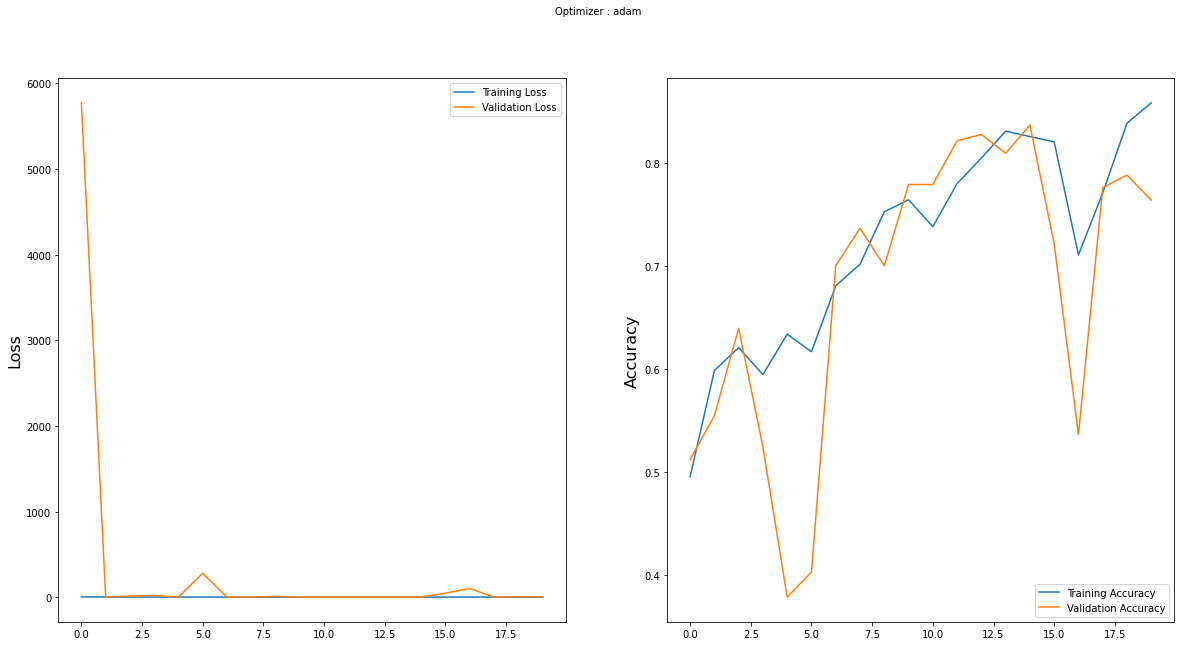

In [56]:
import matplotlib.pyplot as plt

x=hist4
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# MobileNetV2

In [57]:
from tensorflow.keras.applications import MobileNetV2

mob1 = MobileNetV2(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [58]:
x1= Flatten()(mob1.output)
prediction1 = Dense(3, activation='softmax')(x1)
model5 = Model(inputs = mob1.inputs, outputs = prediction1)
model5.summary()
model5.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_8"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_10 (InputLayer)           [(None, 128, 128, 3) 0                                            
__________________________________________________________________________________________________
Conv1 (Conv2D)                  (None, 64, 64, 32)   864         input_10[0][0]                   
__________________________________________________________________________________________________
bn_Conv1 (BatchNormalization)   (None, 64, 64, 32)   128         Conv1[0][0]                      
__________________________________________________________________________________________________
Conv1_relu (ReLU)               (None, 64, 64, 32)   0           bn_Conv1[0][0]                   
____________________________________________________________________________________________

__________________________________________________________________________________________________
block_8_project_BN (BatchNormal (None, 8, 8, 64)     256         block_8_project[0][0]            
__________________________________________________________________________________________________
block_8_add (Add)               (None, 8, 8, 64)     0           block_7_add[0][0]                
                                                                 block_8_project_BN[0][0]         
__________________________________________________________________________________________________
block_9_expand (Conv2D)         (None, 8, 8, 384)    24576       block_8_add[0][0]                
__________________________________________________________________________________________________
block_9_expand_BN (BatchNormali (None, 8, 8, 384)    1536        block_9_expand[0][0]             
__________________________________________________________________________________________________
block_9_ex

In [59]:
hist5 = model5.fit(train_set, validation_data=test_set, epochs=20, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/20


 82/384 [=====>........................] - ETA: 30:20 - loss: 0.3948 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 34s - loss: 5.0748 - accuracy: 0.5000 - f1_m: 0.5000 - precision_m: 0.5000 - recall_m: 0.5000  - ETA: 36s - loss: 6.1568 - accuracy: 0.3333 - f1_m: 0.3333 - precision_m: 0.3333 - recall_m: 0.333 - ETA: 34s - loss: 4.9615 - accuracy: 0.3750 - f1_m: 0.3750 - precision_m: 0.3750 - recall_m: 0.375 - ETA: 34s - loss: 4.1561 - accuracy: 0.4000 - f1_m: 0.4000 - precision_m: 0.4000 - recall_m: 0.400 - ETA: 34s - loss: 3.4778 - accuracy: 0.5000 - f1_m: 0.5000 - precision_m: 0.5000 - recall_m: 0.500 - ETA: 34s - loss: 4.0811 - accuracy: 0.5000 - f1_m: 0.5000 - precision_m: 0.5000 - recall_m: 0.500 - ETA: 34s - loss: 3.5763 - accuracy: 0.5625 - f1_m: 0.5625 - precision_m: 0.5625 - recall_m: 0.562 - ETA: 34s - loss: 3.2880 - accuracy: 0.5556 - f1_m: 0.5556 - precision_m: 0.5556 - recall_m: 0.555 - ETA: 35s - loss: 2.9902 - accuracy: 0.6000 - f1_m: 0.

246/384 [==================>...........] - ETA: 30s - loss: 5.1307 - accuracy: 0.5545 - f1_m: 0.5505 - precision_m: 0.5545 - recall_m: 0.548 - ETA: 30s - loss: 5.1134 - accuracy: 0.5542 - f1_m: 0.5502 - precision_m: 0.5542 - recall_m: 0.548 - ETA: 30s - loss: 5.0917 - accuracy: 0.5539 - f1_m: 0.5499 - precision_m: 0.5539 - recall_m: 0.547 - ETA: 30s - loss: 5.1058 - accuracy: 0.5506 - f1_m: 0.5466 - precision_m: 0.5506 - recall_m: 0.544 - ETA: 30s - loss: 5.1165 - accuracy: 0.5473 - f1_m: 0.5434 - precision_m: 0.5473 - recall_m: 0.541 - ETA: 29s - loss: 5.0941 - accuracy: 0.5471 - f1_m: 0.5431 - precision_m: 0.5471 - recall_m: 0.541 - ETA: 29s - loss: 5.1200 - accuracy: 0.5468 - f1_m: 0.5429 - precision_m: 0.5468 - recall_m: 0.540 - ETA: 29s - loss: 5.1097 - accuracy: 0.5436 - f1_m: 0.5397 - precision_m: 0.5436 - recall_m: 0.537 - ETA: 29s - loss: 5.1333 - accuracy: 0.5405 - f1_m: 0.5366 - precision_m: 0.5405 - recall_m: 0.534 - ETA: 29s - loss: 5.1108 - accuracy: 0.5374 - f1_m: 0.5335

328/384 [========================>.....] - ETA: 19s - loss: 4.0198 - accuracy: 0.5628 - f1_m: 0.5506 - precision_m: 0.5709 - recall_m: 0.540 - ETA: 19s - loss: 4.0197 - accuracy: 0.5625 - f1_m: 0.5484 - precision_m: 0.5685 - recall_m: 0.538 - ETA: 18s - loss: 4.0099 - accuracy: 0.5622 - f1_m: 0.5482 - precision_m: 0.5683 - recall_m: 0.538 - ETA: 18s - loss: 4.0157 - accuracy: 0.5600 - f1_m: 0.5460 - precision_m: 0.5660 - recall_m: 0.536 - ETA: 18s - loss: 4.0023 - accuracy: 0.5598 - f1_m: 0.5465 - precision_m: 0.5677 - recall_m: 0.535 - ETA: 18s - loss: 3.9902 - accuracy: 0.5595 - f1_m: 0.5463 - precision_m: 0.5675 - recall_m: 0.535 - ETA: 18s - loss: 4.0051 - accuracy: 0.5593 - f1_m: 0.5461 - precision_m: 0.5672 - recall_m: 0.535 - ETA: 18s - loss: 3.9909 - accuracy: 0.5591 - f1_m: 0.5466 - precision_m: 0.5689 - recall_m: 0.535 - ETA: 18s - loss: 3.9771 - accuracy: 0.5588 - f1_m: 0.5471 - precision_m: 0.5706 - recall_m: 0.535 - ETA: 17s - loss: 3.9632 - accuracy: 0.5605 - f1_m: 0.5475

384/384 [==============================] - ETA: 7s - loss: 3.3308 - accuracy: 0.5775 - f1_m: 0.5517 - precision_m: 0.5973 - recall_m: 0.52 - ETA: 7s - loss: 3.3218 - accuracy: 0.5788 - f1_m: 0.5530 - precision_m: 0.5985 - recall_m: 0.53 - ETA: 7s - loss: 3.3125 - accuracy: 0.5801 - f1_m: 0.5544 - precision_m: 0.5997 - recall_m: 0.53 - ETA: 7s - loss: 3.3051 - accuracy: 0.5798 - f1_m: 0.5542 - precision_m: 0.5994 - recall_m: 0.53 - ETA: 7s - loss: 3.2952 - accuracy: 0.5811 - f1_m: 0.5556 - precision_m: 0.6006 - recall_m: 0.53 - ETA: 6s - loss: 3.2973 - accuracy: 0.5793 - f1_m: 0.5539 - precision_m: 0.5988 - recall_m: 0.53 - ETA: 6s - loss: 3.2883 - accuracy: 0.5806 - f1_m: 0.5552 - precision_m: 0.6000 - recall_m: 0.53 - ETA: 6s - loss: 3.2889 - accuracy: 0.5789 - f1_m: 0.5536 - precision_m: 0.5982 - recall_m: 0.53 - ETA: 6s - loss: 3.2816 - accuracy: 0.5786 - f1_m: 0.5519 - precision_m: 0.5964 - recall_m: 0.52 - ETA: 6s - loss: 3.2765 - accuracy: 0.5769 - f1_m: 0.5503 - precision_m: 0.5

...

384/384 [==============================] - ETA: 7s - loss: 0.2148 - accuracy: 0.9163 - f1_m: 0.9144 - precision_m: 0.9195 - recall_m: 0.91 - ETA: 7s - loss: 0.2141 - accuracy: 0.9165 - f1_m: 0.9146 - precision_m: 0.9197 - recall_m: 0.91 - ETA: 7s - loss: 0.2149 - accuracy: 0.9153 - f1_m: 0.9134 - precision_m: 0.9184 - recall_m: 0.91 - ETA: 6s - loss: 0.2143 - accuracy: 0.9155 - f1_m: 0.9137 - precision_m: 0.9187 - recall_m: 0.91 - ETA: 6s - loss: 0.2143 - accuracy: 0.9158 - f1_m: 0.9139 - precision_m: 0.9189 - recall_m: 0.91 - ETA: 6s - loss: 0.2136 - accuracy: 0.9160 - f1_m: 0.9142 - precision_m: 0.9192 - recall_m: 0.91 - ETA: 6s - loss: 0.2130 - accuracy: 0.9163 - f1_m: 0.9144 - precision_m: 0.9194 - recall_m: 0.91 - ETA: 6s - loss: 0.2124 - accuracy: 0.9165 - f1_m: 0.9147 - precision_m: 0.9196 - recall_m: 0.91 - ETA: 6s - loss: 0.2121 - accuracy: 0.9168 - f1_m: 0.9149 - precision_m: 0.9199 - recall_m: 0.91 - ETA: 6s - loss: 0.2119 - accuracy: 0.9170 - f1_m: 0.9152 - precision_m: 0.9

 82/384 [=====>........................] - ETA: 42s - loss: 0.3475 - accuracy: 1.0000 - f1_m: 0.6667 - precision_m: 1.0000 - recall_m: 0.500 - ETA: 33s - loss: 0.1738 - accuracy: 1.0000 - f1_m: 0.8333 - precision_m: 1.0000 - recall_m: 0.750 - ETA: 34s - loss: 0.2248 - accuracy: 1.0000 - f1_m: 0.8889 - precision_m: 1.0000 - recall_m: 0.833 - ETA: 34s - loss: 0.1686 - accuracy: 1.0000 - f1_m: 0.9167 - precision_m: 1.0000 - recall_m: 0.875 - ETA: 34s - loss: 0.1748 - accuracy: 1.0000 - f1_m: 0.9333 - precision_m: 1.0000 - recall_m: 0.900 - ETA: 34s - loss: 0.1520 - accuracy: 1.0000 - f1_m: 0.9444 - precision_m: 1.0000 - recall_m: 0.916 - ETA: 34s - loss: 0.1875 - accuracy: 0.9286 - f1_m: 0.9048 - precision_m: 1.0000 - recall_m: 0.857 - ETA: 34s - loss: 0.1791 - accuracy: 0.9375 - f1_m: 0.9167 - precision_m: 1.0000 - recall_m: 0.875 - ETA: 34s - loss: 0.1745 - accuracy: 0.9444 - f1_m: 0.9259 - precision_m: 1.0000 - recall_m: 0.888 - ETA: 34s - loss: 0.1866 - accuracy: 0.9500 - f1_m: 0.9333

246/384 [==================>...........] - ETA: 28s - loss: 0.1808 - accuracy: 0.9394 - f1_m: 0.9303 - precision_m: 0.9424 - recall_m: 0.924 - ETA: 28s - loss: 0.1799 - accuracy: 0.9398 - f1_m: 0.9307 - precision_m: 0.9428 - recall_m: 0.924 - ETA: 28s - loss: 0.1793 - accuracy: 0.9401 - f1_m: 0.9311 - precision_m: 0.9431 - recall_m: 0.925 - ETA: 28s - loss: 0.1787 - accuracy: 0.9405 - f1_m: 0.9315 - precision_m: 0.9435 - recall_m: 0.925 - ETA: 27s - loss: 0.1786 - accuracy: 0.9408 - f1_m: 0.9320 - precision_m: 0.9438 - recall_m: 0.926 - ETA: 27s - loss: 0.1776 - accuracy: 0.9412 - f1_m: 0.9324 - precision_m: 0.9441 - recall_m: 0.926 - ETA: 27s - loss: 0.1765 - accuracy: 0.9415 - f1_m: 0.9327 - precision_m: 0.9444 - recall_m: 0.926 - ETA: 27s - loss: 0.1757 - accuracy: 0.9419 - f1_m: 0.9331 - precision_m: 0.9448 - recall_m: 0.927 - ETA: 27s - loss: 0.1759 - accuracy: 0.9422 - f1_m: 0.9335 - precision_m: 0.9451 - recall_m: 0.927 - ETA: 27s - loss: 0.1752 - accuracy: 0.9425 - f1_m: 0.9339

328/384 [========================>.....] - ETA: 18s - loss: 0.1835 - accuracy: 0.9310 - f1_m: 0.9258 - precision_m: 0.9352 - recall_m: 0.921 - ETA: 17s - loss: 0.1828 - accuracy: 0.9313 - f1_m: 0.9261 - precision_m: 0.9355 - recall_m: 0.921 - ETA: 17s - loss: 0.1834 - accuracy: 0.9316 - f1_m: 0.9264 - precision_m: 0.9357 - recall_m: 0.921 - ETA: 17s - loss: 0.1826 - accuracy: 0.9319 - f1_m: 0.9267 - precision_m: 0.9360 - recall_m: 0.922 - ETA: 17s - loss: 0.1846 - accuracy: 0.9301 - f1_m: 0.9250 - precision_m: 0.9343 - recall_m: 0.920 - ETA: 17s - loss: 0.1838 - accuracy: 0.9304 - f1_m: 0.9253 - precision_m: 0.9345 - recall_m: 0.920 - ETA: 17s - loss: 0.1831 - accuracy: 0.9307 - f1_m: 0.9256 - precision_m: 0.9348 - recall_m: 0.920 - ETA: 17s - loss: 0.1824 - accuracy: 0.9310 - f1_m: 0.9259 - precision_m: 0.9350 - recall_m: 0.921 - ETA: 17s - loss: 0.1819 - accuracy: 0.9312 - f1_m: 0.9261 - precision_m: 0.9353 - recall_m: 0.921 - ETA: 16s - loss: 0.1830 - accuracy: 0.9295 - f1_m: 0.9245

384/384 [==============================] - ETA: 7s - loss: 0.1757 - accuracy: 0.9315 - f1_m: 0.9265 - precision_m: 0.9347 - recall_m: 0.92 - ETA: 7s - loss: 0.1753 - accuracy: 0.9317 - f1_m: 0.9268 - precision_m: 0.9348 - recall_m: 0.92 - ETA: 7s - loss: 0.1748 - accuracy: 0.9319 - f1_m: 0.9270 - precision_m: 0.9350 - recall_m: 0.92 - ETA: 6s - loss: 0.1763 - accuracy: 0.9306 - f1_m: 0.9257 - precision_m: 0.9337 - recall_m: 0.92 - ETA: 6s - loss: 0.1785 - accuracy: 0.9293 - f1_m: 0.9244 - precision_m: 0.9324 - recall_m: 0.92 - ETA: 6s - loss: 0.1781 - accuracy: 0.9295 - f1_m: 0.9247 - precision_m: 0.9326 - recall_m: 0.92 - ETA: 6s - loss: 0.1785 - accuracy: 0.9297 - f1_m: 0.9249 - precision_m: 0.9328 - recall_m: 0.92 - ETA: 6s - loss: 0.1779 - accuracy: 0.9300 - f1_m: 0.9251 - precision_m: 0.9330 - recall_m: 0.92 - ETA: 6s - loss: 0.1808 - accuracy: 0.9287 - f1_m: 0.9238 - precision_m: 0.9318 - recall_m: 0.91 - ETA: 6s - loss: 0.1811 - accuracy: 0.9289 - f1_m: 0.9241 - precision_m: 0.9

In [100]:
mob_acc = hist5.history["val_accuracy"][19]
mob_prec = hist5.history["val_precision_m"][19]
mob_rec = hist5.history["val_recall_m"][19]
mob_f1 = hist5.history["val_f1_m"][19]

In [106]:
storeResults('MobileNetV2',mob_acc,mob_prec,mob_rec,mob_f1)

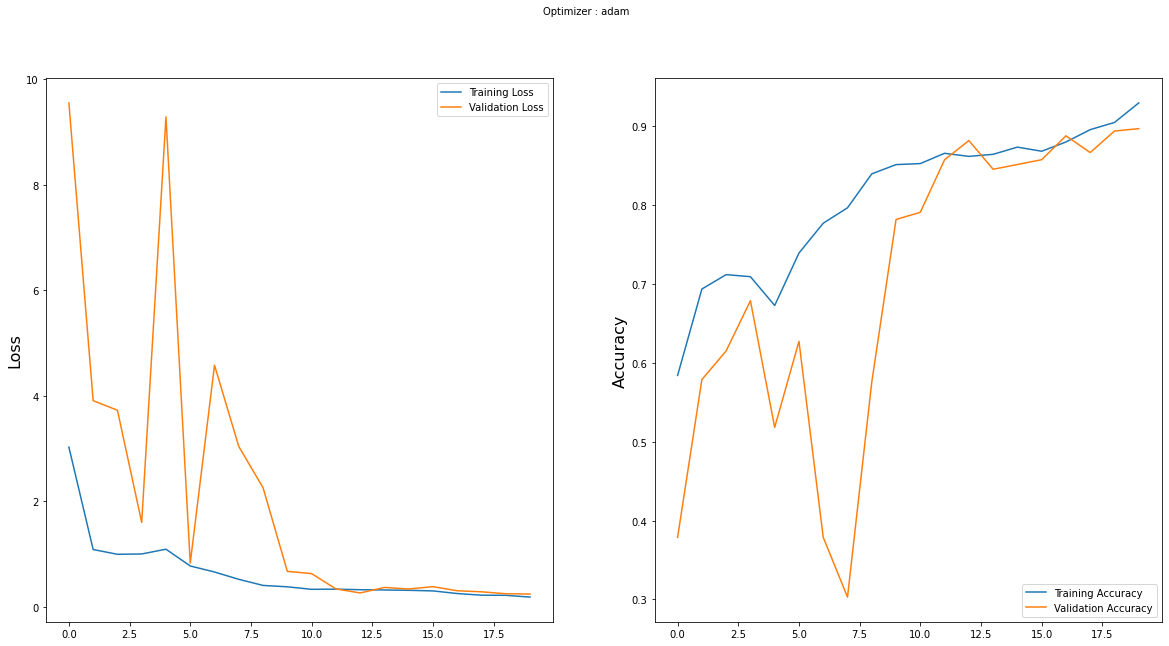

In [60]:
import matplotlib.pyplot as plt

x=hist5
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# Xception

In [88]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.optimizers import Adam

In [89]:
# Defining the pretrained base model
base = Xception(include_top=False, weights='imagenet', input_shape=(128,128,3))
x = base.output
x = GlobalAveragePooling2D()(x)
# Defining the head of the model where the prediction is conducted
head = Dense(3, activation='softmax')(x)
# Combining base and head 
model6 = Model(inputs=base.input, outputs=head)

In [90]:
model6.compile(optimizer='sgd', 
              loss = 'categorical_crossentropy', 
              metrics=["accuracy",f1_m,precision_m, recall_m])

In [92]:
hist6 = model6.fit(train_set, validation_data=test_set, epochs=20, steps_per_epoch=len(train_set), validation_steps=len(test_set))

Epoch 1/20


 81/384 [=====>........................] - ETA: 2:05 - loss: 0.0016 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:59 - loss: 8.2599e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:58 - loss: 0.0010 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000   - ETA: 1:59 - loss: 9.6086e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 2:00 - loss: 0.0010 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000   - ETA: 2:00 - loss: 9.6742e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:59 - loss: 0.0011 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000   - ETA: 1:58 - loss: 9.5471e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:57 - loss: 8.4903e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:57 - loss: 7.9285e

245/384 [==================>...........] - ETA: 1:47 - loss: 0.0026 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:47 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:46 - loss: 0.0026 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:46 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:45 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:45 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:44 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:44 - loss: 0.0026 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:43 - loss: 0.0026 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:43 - loss: 0.0026 - accuracy: 1.0000 - f1_m: 1.000

327/384 [========================>.....] - ETA: 1:07 - loss: 0.0020 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:07 - loss: 0.0020 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:06 - loss: 0.0020 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:06 - loss: 0.0020 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:05 - loss: 0.0020 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:05 - loss: 0.0020 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:04 - loss: 0.0020 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:04 - loss: 0.0020 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:03 - loss: 0.0020 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:03 - loss: 0.0019 - accuracy: 1.0000 - f1_m: 1.000

384/384 [==============================] - ETA: 27s - loss: 0.0024 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 26s - loss: 0.0024 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 26s - loss: 0.0024 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 25s - loss: 0.0024 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 25s - loss: 0.0024 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 24s - loss: 0.0024 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 24s - loss: 0.0024 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 23s - loss: 0.0024 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 23s - loss: 0.0024 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 23s - loss: 0.0024 - accuracy: 1.0000 - f1_m: 1.0000

...

384/384 [==============================] - ETA: 26s - loss: 0.0062 - accuracy: 0.9985 - f1_m: 0.9985 - precision_m: 0.9985 - recall_m: 0.998 - ETA: 26s - loss: 0.0061 - accuracy: 0.9985 - f1_m: 0.9985 - precision_m: 0.9985 - recall_m: 0.998 - ETA: 25s - loss: 0.0061 - accuracy: 0.9985 - f1_m: 0.9985 - precision_m: 0.9985 - recall_m: 0.998 - ETA: 25s - loss: 0.0061 - accuracy: 0.9985 - f1_m: 0.9985 - precision_m: 0.9985 - recall_m: 0.998 - ETA: 24s - loss: 0.0061 - accuracy: 0.9985 - f1_m: 0.9985 - precision_m: 0.9985 - recall_m: 0.998 - ETA: 24s - loss: 0.0061 - accuracy: 0.9985 - f1_m: 0.9985 - precision_m: 0.9985 - recall_m: 0.998 - ETA: 23s - loss: 0.0061 - accuracy: 0.9985 - f1_m: 0.9985 - precision_m: 0.9985 - recall_m: 0.998 - ETA: 23s - loss: 0.0060 - accuracy: 0.9985 - f1_m: 0.9985 - precision_m: 0.9985 - recall_m: 0.998 - ETA: 22s - loss: 0.0060 - accuracy: 0.9985 - f1_m: 0.9985 - precision_m: 0.9985 - recall_m: 0.998 - ETA: 22s - loss: 0.0060 - accuracy: 0.9985 - f1_m: 0.9985

 82/384 [=====>........................] - ETA: 3:25 - loss: 7.9274e-06 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 2:58 - loss: 7.9325e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 3:00 - loss: 6.0299e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 3:01 - loss: 0.0031 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000   - ETA: 3:01 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 3:00 - loss: 0.0023 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 2:59 - loss: 0.0021 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 2:59 - loss: 0.0018 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 2:59 - loss: 0.0016 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 2:59 - loss: 0.0015 - accuracy: 1.00

246/384 [==================>...........] - ETA: 1:46 - loss: 0.0028 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:45 - loss: 0.0027 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:45 - loss: 0.0027 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:44 - loss: 0.0027 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:44 - loss: 0.0027 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:43 - loss: 0.0027 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:43 - loss: 0.0027 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:42 - loss: 0.0027 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:42 - loss: 0.0026 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:41 - loss: 0.0026 - accuracy: 1.0000 - f1_m: 1.000

328/384 [========================>.....] - ETA: 1:06 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:06 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:05 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:05 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:04 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:04 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:03 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:03 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:02 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.00 - ETA: 1:02 - loss: 0.0025 - accuracy: 1.0000 - f1_m: 1.000

384/384 [==============================] - ETA: 26s - loss: 0.0032 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 26s - loss: 0.0032 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 25s - loss: 0.0032 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 25s - loss: 0.0032 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 24s - loss: 0.0032 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 24s - loss: 0.0032 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 23s - loss: 0.0032 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 23s - loss: 0.0032 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 22s - loss: 0.0032 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.000 - ETA: 22s - loss: 0.0032 - accuracy: 1.0000 - f1_m: 1.0000

In [101]:
xec_acc = hist6.history["val_accuracy"][19]
xec_prec = hist6.history["val_precision_m"][19]
xec_rec = hist6.history["val_recall_m"][19]
xec_f1 = hist6.history["val_f1_m"][19]

In [115]:
storeResults('Xception',xec_acc,xec_prec,xec_rec,xec_f1)

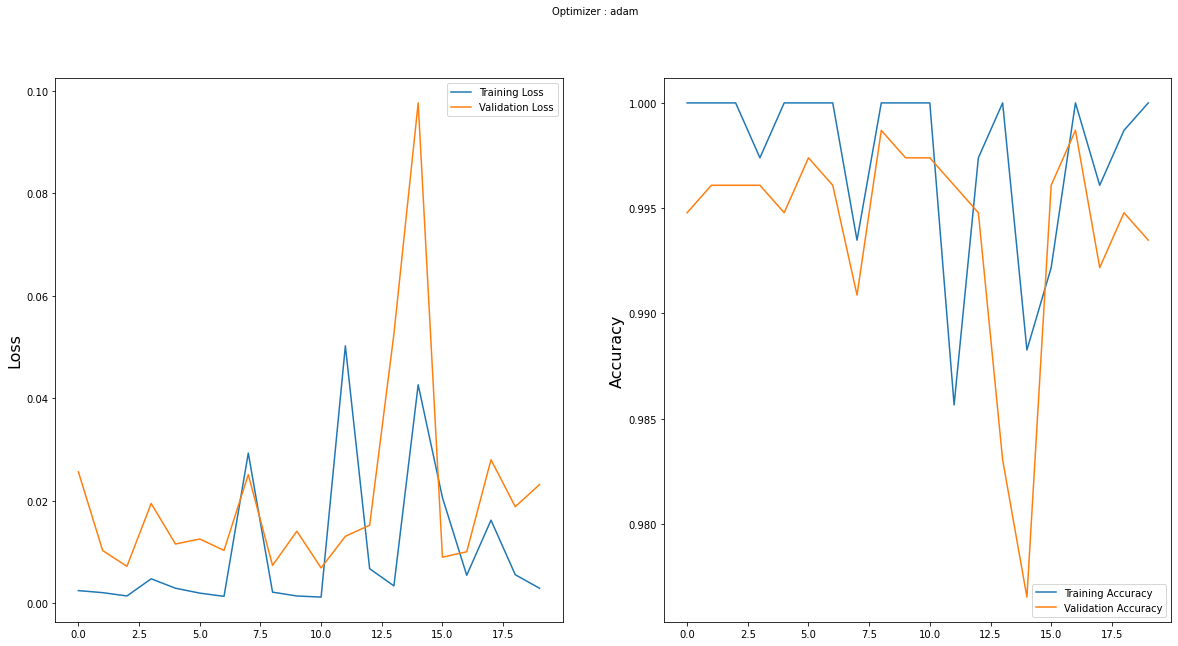

In [93]:
import matplotlib.pyplot as plt

x=hist6
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# RetinaNet backbone of ResNet

In [65]:
import torch
import torch.nn.functional as F
import torchvision
from torchvision import datasets,transforms
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models

In [66]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [67]:
IMGSIZE = 128
transform1 = transforms.Compose([transforms.RandomHorizontalFlip(),
                                transforms.RandomRotation(0.2),
                                transforms.ToTensor(),
                                transforms.Resize((IMGSIZE,IMGSIZE))
                               ])

In [68]:
full_data = torchvision.datasets.ImageFolder(root = 'output/train', transform = transform1)

In [69]:
classes = full_data.classes
print("Classes:",classes)
num_classes = len(full_data.classes)
print("Number of Classes:",num_classes)

Classes: ['Bengin', 'Malignant', 'Normal']
Number of Classes: 3


In [70]:
train_data, test_data = torch.utils.data.random_split(full_data, [500, 267])

In [71]:
train_loader = torch.utils.data.DataLoader(dataset = train_data, batch_size = 46, shuffle = True)

test_loader = torch.utils.data.DataLoader(dataset = test_data, batch_size = 46, shuffle = True)

In [72]:
def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize = True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize = (10, 10))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)
        
        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

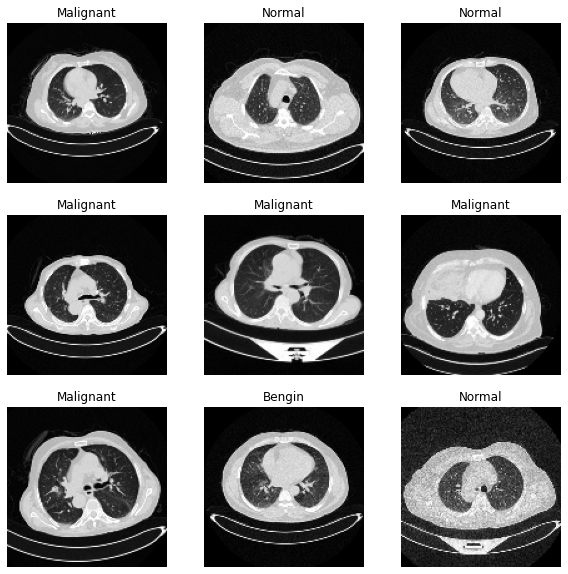

In [73]:
N_IMAGES = 9

images, labels = zip(*[(image, label) for image, label in [train_data[i] for i in range(N_IMAGES)]])

classes = full_data.classes

plot_images(images, labels, classes)

In [74]:
model7 = models.resnet50(pretrained=True)

In [75]:
print(model7)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

)


In [76]:
q = model7.fc.in_features
model7.fc = nn.Linear(q, num_classes)

model7 = model7.cpu()

In [77]:
criter = nn.CrossEntropyLoss()
optimz = torch.optim.Adam(model7.parameters(),lr=1e-5,weight_decay=1e-5)

In [78]:
TrainLoss = []
TrainAcc = []
TestLoss = []
TestAcc = []
num_epochs = 20

In [79]:
# Train the model
total_step = len(train_loader)

for epoch in range(num_epochs):
    trainAcc = 0
    testAcc = 0
    for i, (images, labels) in enumerate(train_loader):
        model7.train()
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model7(images)
        trainloss = criter(outputs, labels)
        
        # Backward and optimize
        optimz.zero_grad()
        trainloss.backward()
        optimz.step()
        
        # Checking accuracy
        preds = outputs.data.max(dim=1,keepdim=True)[1]
        trainAcc += preds.eq(labels.data.view_as(preds)).cpu().sum()
    
    trainAcc = trainAcc/len(train_loader.dataset) * 100
    
    for i, (images, labels) in enumerate(test_loader):
        model7.eval()
        images = images.to(device)
        labels = labels.to(device)
    
        # Forward pass
        outputs = model7(images)
        testloss = criter(outputs, labels)
    
        # Checking accuracy
        preds = outputs.data.max(dim=1,keepdim=True)[1]
        testAcc += preds.eq(labels.data.view_as(preds)).cpu().sum()
    
    testAcc = testAcc/len(test_loader.dataset) * 100
    
    print("Epoch {} =>  Train Loss : {trainloss:.2f};   Train Accuracy : {trainAcc:.2f}%;   Test Loss : {testloss:.2f};   Test Accuracy : {testAcc:.2f}%".format(epoch+1, trainloss=trainloss.item(), trainAcc=trainAcc, testloss=testloss.item(), testAcc=testAcc))
  
    TrainLoss.append(trainloss)
    TrainAcc.append(trainAcc)

    TestLoss.append(testloss)
    TestAcc.append(testAcc)

Epoch 1 =>  Train Loss : 0.82;   Train Accuracy : 55.80%;   Test Loss : 1.01;   Test Accuracy : 57.30%
Epoch 2 =>  Train Loss : 0.61;   Train Accuracy : 86.20%;   Test Loss : 0.86;   Test Accuracy : 75.66%
Epoch 3 =>  Train Loss : 0.53;   Train Accuracy : 89.80%;   Test Loss : 0.69;   Test Accuracy : 80.52%
Epoch 4 =>  Train Loss : 0.36;   Train Accuracy : 92.20%;   Test Loss : 0.57;   Test Accuracy : 86.14%
Epoch 5 =>  Train Loss : 0.26;   Train Accuracy : 93.80%;   Test Loss : 0.58;   Test Accuracy : 88.76%
Epoch 6 =>  Train Loss : 0.18;   Train Accuracy : 96.00%;   Test Loss : 0.37;   Test Accuracy : 90.26%
Epoch 7 =>  Train Loss : 0.19;   Train Accuracy : 96.00%;   Test Loss : 0.33;   Test Accuracy : 90.26%
Epoch 8 =>  Train Loss : 0.13;   Train Accuracy : 98.40%;   Test Loss : 0.29;   Test Accuracy : 93.63%
Epoch 9 =>  Train Loss : 0.11;   Train Accuracy : 99.20%;   Test Loss : 0.23;   Test Accuracy : 95.88%
Epoch 10 =>  Train Loss : 0.12;   Train Accuracy : 99.40%;   Test Loss : 

In [80]:
import torch
from torch import optim,nn
from torch.autograd import Variable
from torch.utils.data import DataLoader,Dataset
from torchvision import models,transforms

In [81]:
model7.eval()
y_label = []
y_predict = []
with torch.no_grad():
    for i, data in enumerate(test_loader):
        images, labels = data
        N = images.size(0)
        #images = criter(outputs, labels).to(device)
        outputs = model7(images)
        prediction = outputs.max(1, keepdim=True)[1]
        y_label.extend(labels.cpu().numpy())
        y_predict.extend(np.squeeze(prediction.cpu().numpy().T))

In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [84]:
retina_acc = accuracy_score(y_label, y_predict)
retina_prec = precision_score(y_label, y_predict,average='weighted')
retina_rec = recall_score(y_label, y_predict,average='weighted')
retina_f1 = f1_score(y_label, y_predict,average='weighted')

In [107]:
storeResults('RetinaNet',retina_acc,retina_prec,retina_rec,retina_f1)

In [86]:
# Save the model checkpoint
#torch.save(googlenet.state_dict(), 'GoogleNetModel.ckpt')
torch.save(model7.state_dict(), 'retinanet.pth')

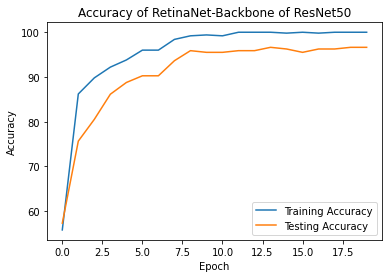

In [87]:
plt.plot(range(20),TrainAcc)
plt.plot(range(20),TestAcc)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.title("Accuracy of RetinaNet-Backbone of ResNet50")
plt.legend(["Training Accuracy", "Testing Accuracy"])
plt.show()

# Comparison

In [116]:
#creating dataframe
import pandas as pd
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                       'Precision': precision,
                       'Recall'   : recall, 
                       'F1_score' : f1score,
                        
                        
                      })

In [117]:
result

,ML Model,Accuracy,Precision,Recall,F1_score
0,VGG16,0.512,0.512,0.512,0.512
1,DenseNet201,0.800,0.830,0.782,0.798
2,EfficientNetB2,0.758,0.764,0.742,0.749
3,ResNet101,0.764,0.773,0.758,0.763
4,MobileNetV2,0.897,0.909,0.876,0.887
5,RetinaNet,0.966,0.966,0.966,0.965
6,Xception,0.993,0.993,0.993,0.993


# Modelling

In [118]:
model6.save('model.h5')

# Graph

In [119]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

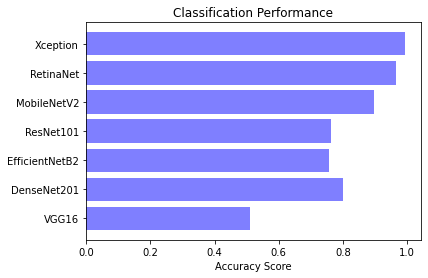

In [120]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

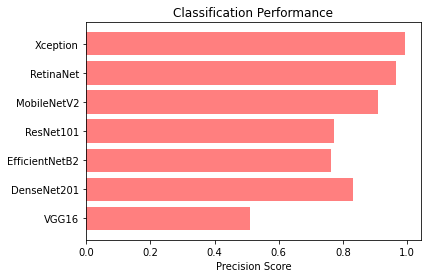

In [121]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

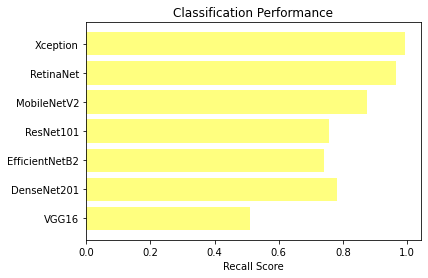

In [122]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 SCore

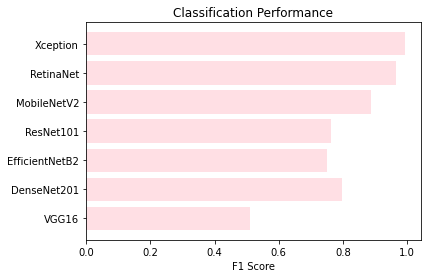

In [123]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='pink')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()